# ✈️ NASA C-MAPSS FD001 — EDA + 전처리 파이프라인 (결정 1~4)

---
**목적:** 전처리 전 EDA → 결정 1~4 적용 → 전처리 후 검증 → CSV 저장  
**대상:** FD001 (단일 운전 조건, HPC 열화만)  
**출력:** `preprocessed/FD001_train_preprocessed.csv` / `FD001_test_preprocessed.csv` / `FD001_test_RUL.csv`

---
### 노트북 흐름
```
[0] 환경 설정
[1] 데이터 로딩 & 컬럼명 표준화
[2] 전처리 전 EDA
     ├─ 2-1. 기초 통계 & 데이터 품질
     ├─ 2-2. 엔진 수명 분포
     ├─ 2-3. 센서 분포 & 이상치
     ├─ 2-4. 센서 간 상관관계 히트맵
     ├─ 2-5. 센서별 열화 트렌드
     ├─ 2-6. ADF 정상성 검정
     └─ 2-7. RUL 상관계수
[3] 결정 1 — 상수 센서 제거 (21→14)
[4] 결정 2 — Piecewise RUL (Cap=125)
[5] 결정 3 — Gaussian 스무딩 (σ=2)
[6] 결정 4 — MinMax 정규화
[7] 전처리 후 검증 (전후 비교)
     ├─ 7-1. 상관관계 전후 비교
     ├─ 7-2. ADF 검정 전후 비교
     ├─ 7-3. 센서 분포 전후 비교
     ├─ 7-4. Train vs Test 분포 비교
     └─ 7-5. 열화 트렌드 전후 비교
[8] CSV 저장 & 최종 요약
```

## 0. 환경 설정

In [5]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ──────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ──────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')

✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01


## 1. 데이터 로딩 & 컬럼명 표준화

In [6]:
DATA_DIR = '../YJ'

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD001.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD001 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD001 로딩 완료
   Train : (20631, 26)  |  엔진 100대
   Test  : (13096, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [7]:
print(train_raw.columns.tolist())

['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


In [8]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

# 결측치·중복·음수 확인
quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

# 센서별 기술통계
print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,20631,0,0,0,100,✅ 정상
Test,13096,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.6809,0.5001,641.2100,644.5300,0.0008
s_3,1590.5231,6.1311,1571.0400,1616.9100,0.0039
s_4,1408.9338,9.0006,1382.2500,1441.4900,0.0064
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.6098,0.0014,21.6000,21.6100,0.0001
s_7,553.3677,0.8851,549.8500,556.0600,0.0016
s_8,2388.0967,0.0710,2387.9000,2388.5600,0.0000
s_9,9065.2429,22.0829,9021.7300,9244.5900,0.0024
s_10,1.3000,0.0000,1.3000,1.3000,0.0000



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상


### 📊 2-1. 기초 통계 & 데이터 품질 검사 결과

---

#### 데이터 품질 확인
| 항목 | Train | Test |
|------|-------|------|
| 전체 행 | 20,631 | 13,096 |
| 결측치 | 0 | 0 |
| 중복 행 | 0 | 0 |
| 음수 센서 | 0 | 0 |
| 엔진 수 | 100 | 100 |

> ✅ 결측치, 중복, 음수 전부 없음  
> → C-MAPSS는 컴퓨터 시뮬레이션 데이터라 매우 깨끗함  
> → 별도 결측치 처리 불필요

---

#### CV(변동계수) 해석
> CV = std / mean → 값이 클수록 센서가 많이 변함  
> CV ≈ 0 → 비행 내내 거의 같은 값 → 열화 정보 없음 → 제거 대상

**상수 센서 (CV ≈ 0, 제거 대상)**
| 센서 | CV | 판정 |
|------|----|------|
| s_1 | 0.0000 | 완전 상수 |
| s_5 | 0.0000 | 완전 상수 |
| s_6 | 0.0001 | 사실상 상수 |
| s_10 | 0.0000 | 완전 상수 |
| s_16 | 0.0000 | 완전 상수 |
| s_18 | 0.0000 | 완전 상수 |
| s_19 | 0.0000 | 완전 상수 |

**유용 센서 (CV > 0, 유지 대상)**
| 센서 | CV | 특징 |
|------|----|------|
| s_4 | 0.0064 | 가장 변동 큼 → 열화 신호 강함 |
| s_20 | 0.0047 | 변동 큼 |
| s_21 | 0.0046 | 변동 큼 |
| s_15 | 0.0044 | 변동 큼 |
| s_11 | 0.0056 | 변동 큼 |

> 💡 CV가 크다고 무조건 좋은 센서는 아님  
> → 이후 RUL 상관계수 분석에서 실제 열화와 연관된 센서 확인 예정

---

#### 🔑 핵심 결론
> **데이터 품질 이상 없음**  
> **s_1, s_5, s_6, s_10, s_16, s_18, s_19 → 상수 센서 → 제거 대상**  
> **나머지 14개 센서 → 열화 정보 포함 가능 → 유지**

### 2-2. 엔진 수명 분포

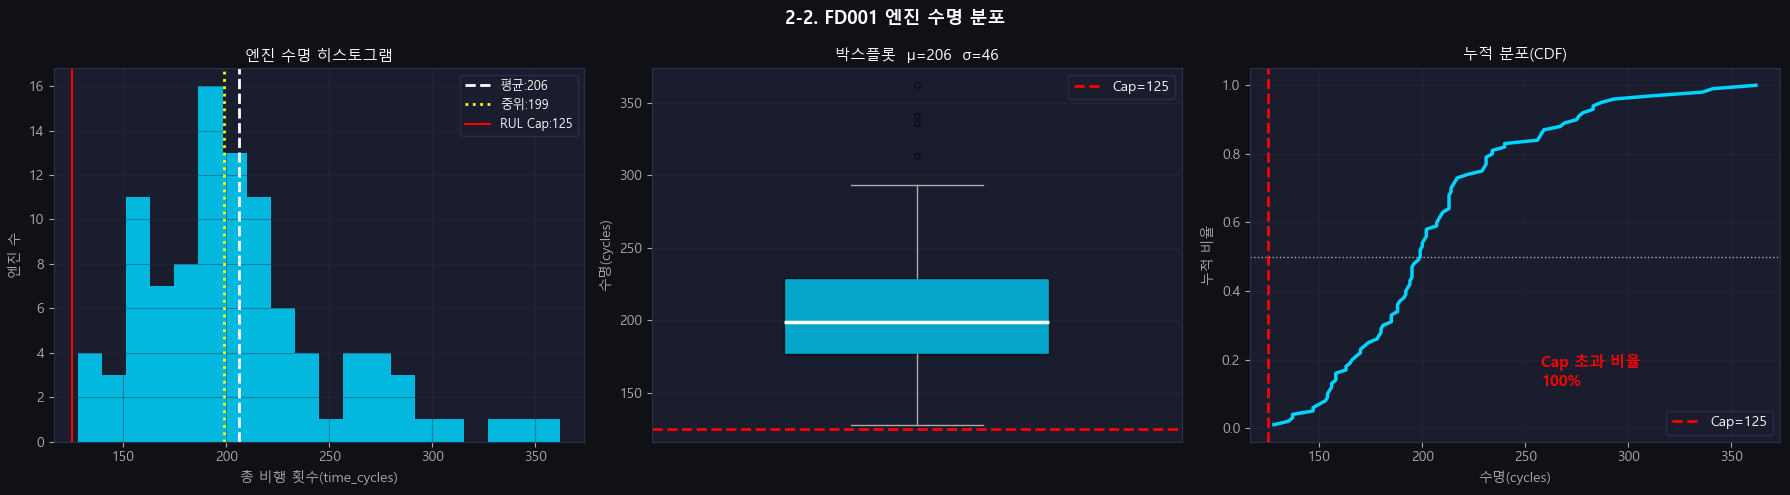


엔진 수명 통계:
  평균=206.3  중위=199.0  min=128  max=362
  Cap=125 초과 엔진: 100대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [9]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD001 엔진 수명 분포', fontsize=13, fontweight='bold')

# 히스토그램
ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)')
ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([])
ax.legend()

# CDF
ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')

### 📊 2-2. 엔진 수명 분포 분석 결과

---

#### 히스토그램 해석
- x축: 총 비행 횟수 (엔진 수명)
- y축: 해당 수명을 가진 엔진 수
- **150~250 구간에 엔진이 가장 많이 분포**
- 평균 206번, 중위수 199번으로 비슷 → 분포가 크게 치우치지 않음
- 빨간 수직선(Cap=125): 모든 엔진이 이 선 오른쪽에 위치
  → **어떤 엔진도 125사이클 이전에 고장나지 않음**

---

#### 박스플롯 해석
- 박스(25~75%): 대부분 엔진이 175~250 사이클 수명
- 흰 가로선(중위수): 199사이클
- 수염 끝(최솟값~최댓값): 128~362
- 빨간 점선(Cap=125): 박스 전체가 Cap 위에 있음
  → **Cap=125가 어떤 엔진의 정상 구간도 침범하지 않음을 증명**

---

#### CDF(누적 분포) 해석
- x축: 수명, y축: 누적 비율(0~1)
- 곡선이 빨간 점선(Cap=125)을 만나는 y값 = 0
  → **Cap=125 이하 엔진이 0% = 100% 엔진이 Cap 초과**
- 곡선이 0.5를 만나는 x값 ≈ 199 → 중위수 확인

---

#### 🔑 핵심 결론
> **모든 엔진(100%)의 수명이 125사이클을 초과**  
> → 125사이클 이하 구간은 열화와 무관한 정상 운전 구간  
> → 이 구간의 RUL을 전부 125로 고정해도 실제 정보 손실 없음  
> → **Cap=125 설정의 데이터 기반 근거**

### 2-3. 센서 분포 & 이상치 (전처리 전)

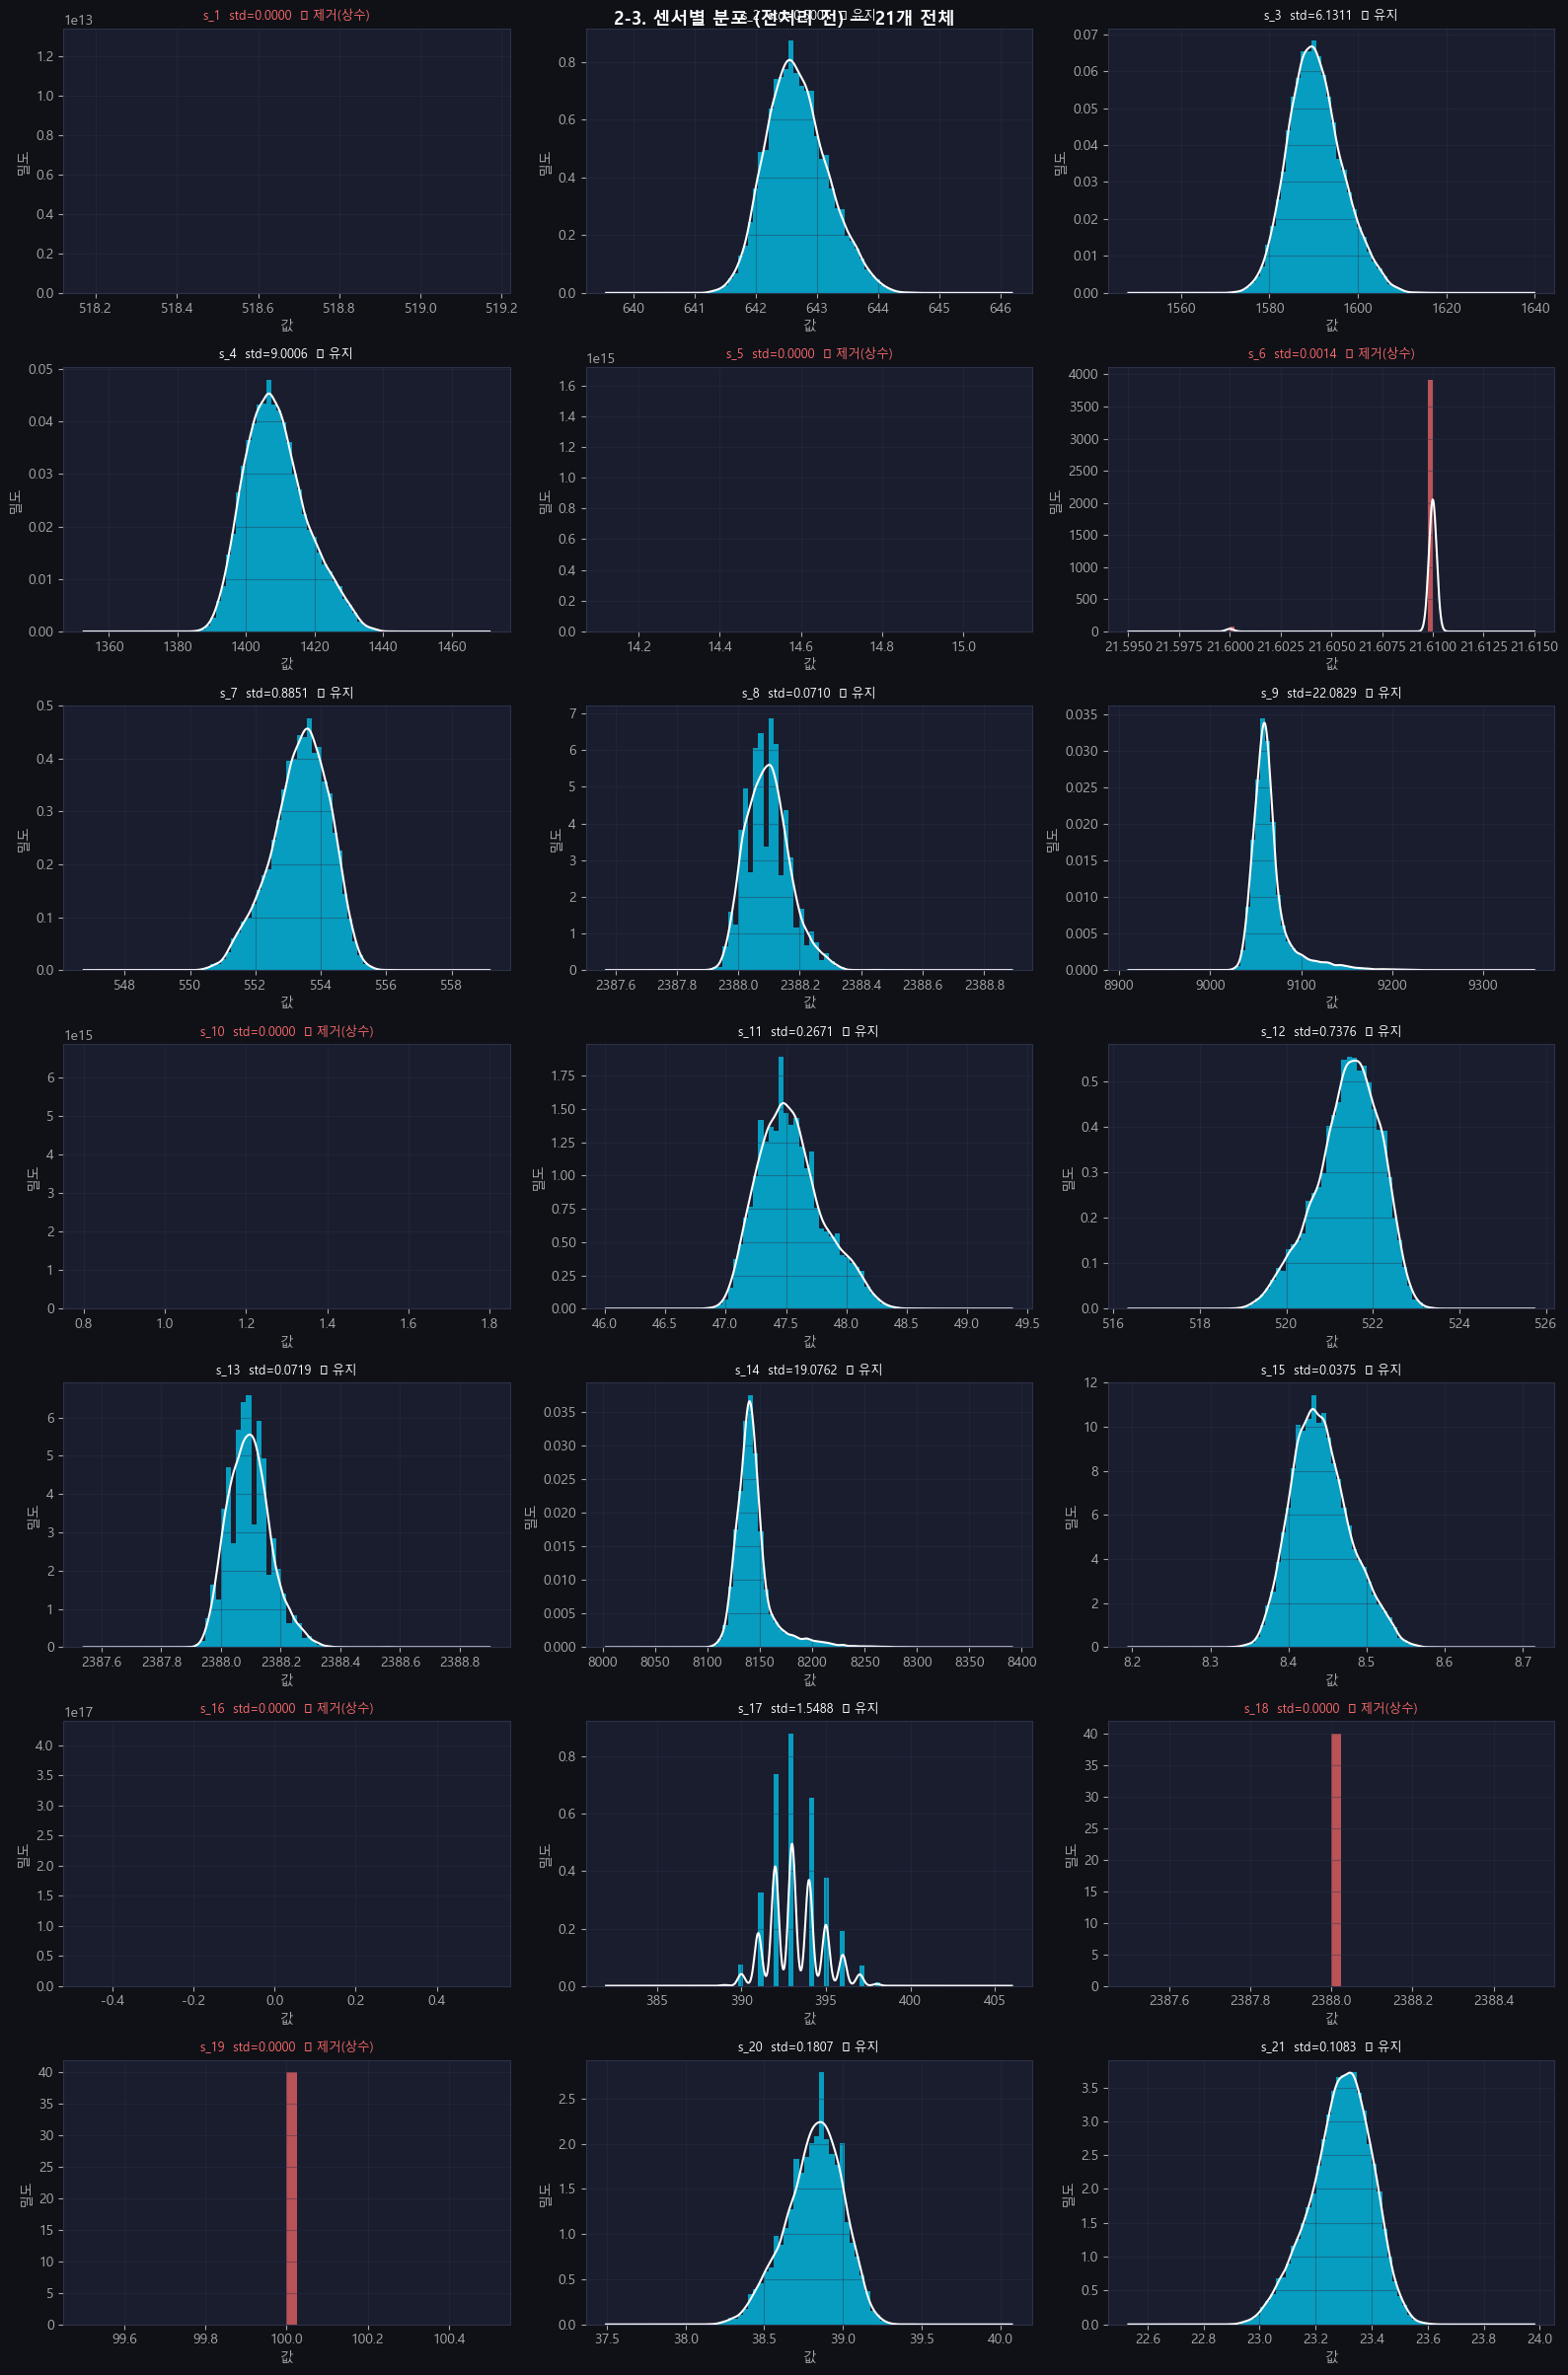

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,128,0.620
2,s_3,165,0.800
3,s_4,120,0.582
5,s_6,406,1.968
6,s_7,110,0.533
7,s_8,320,1.551
8,s_9,1686,8.172
10,s_11,167,0.809
11,s_12,146,0.708
12,s_13,161,0.780


In [10]:
# 21개 센서 분포 (히스토그램 + KDE)
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try:
        data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# IQR 이상치 탐지
print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero):
    display(nonzero)
else:
    print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 📊 2-3. 센서별 분포 & 이상치 탐지 결과

---

#### 센서 분포 시각화 해석
- **빨간색 센서 (상수, 제거 대상):** s_1, s_5, s_6, s_10, s_16, s_18, s_19
  → 막대가 한 점에만 집중 = 값이 전혀 변하지 않음
- **파란색 센서 (유용, 유지):** 나머지 14개
  → 종 모양 분포 = 값이 다양하게 변함 = 열화 정보 포함 가능

> 💡 s_9, s_14는 분포가 왼쪽으로 치우쳐 있음 (왼쪽 꼬리)
> → 고장 직전 낮아지는 값들이 존재한다는 의미
> → 열화 신호일 가능성 있음 → 이상치로 제거하면 안됨

> 💡 s_8은 다봉분포 형태
> - 다봉분포란? 봉우리가 여러 개인 분포
> - 단봉분포: 값이 하나의 중심으로 모임 (대부분 센서)
> - 다봉분포: 값이 여러 군데로 나뉘어 모임 (s_8)
> - s_8 = Nf 팬 속도(rpm) → 비행 단계(이륙/순항/착륙)마다
>   팬 속도가 달라져서 봉우리가 여러 개 생김
> - FD001은 단일 운전조건이라 이론적으로는 단봉이어야 하는데
>   다봉이 나온 것 → 주의깊게 봐야 할 센서

---

#### IQR 이상치 탐지 결과

| 센서 | 이상치 수 | 비율(%) | 비고 |
|------|---------|---------|------|
| s_9  | 1,686 | 8.172 | 가장 높음 ⚠️ |
| s_14 | 1,543 | 7.479 | 두 번째 ⚠️ |
| s_8  | 320 | 1.551 | 다봉분포 영향 |
| s_6  | 406 | 1.968 | 상수 센서라 제거 예정 |
| 나머지 | 81~167 | 0.4~0.8 | 낮은 수준 |

---

#### 🔑 핵심 결론

**① s_9, s_14 이상치 비율이 높은 이유**
- s_9 = Nc 코어 속도(rpm), s_14 = NRc 보정 코어속도
- 둘의 상관계수 r=0.96 → 거의 같은 정보
- 고장 직전 급격히 낮아지는 값들이 IQR 기준으로 이상치로 잡힘
- 실제로는 열화 신호 → 제거하면 안됨 ✅

**② 전체적으로 이상치 비율이 낮음**
- 대부분 센서 0.4~0.8% 수준
- 시뮬레이션 데이터 특성상 깨끗한 데이터
- 별도 이상치 처리 불필요
- 튜터님 피드백: 이상치 = 열화 신호일 수 있음 → 제거 금지

**③ s_9, s_14 로그 변환 논의 근거**
- 높은 이상치 비율 = 분포가 한쪽으로 치우쳐 있다는 증거
- 단, 제거가 아닌 분포 보정 목적으로만 고려
- 1차 공통 전처리 후 모델 실험 단계에서 결정 예정

### 2-4. 센서 간 상관관계 히트맵 (전처리 전)

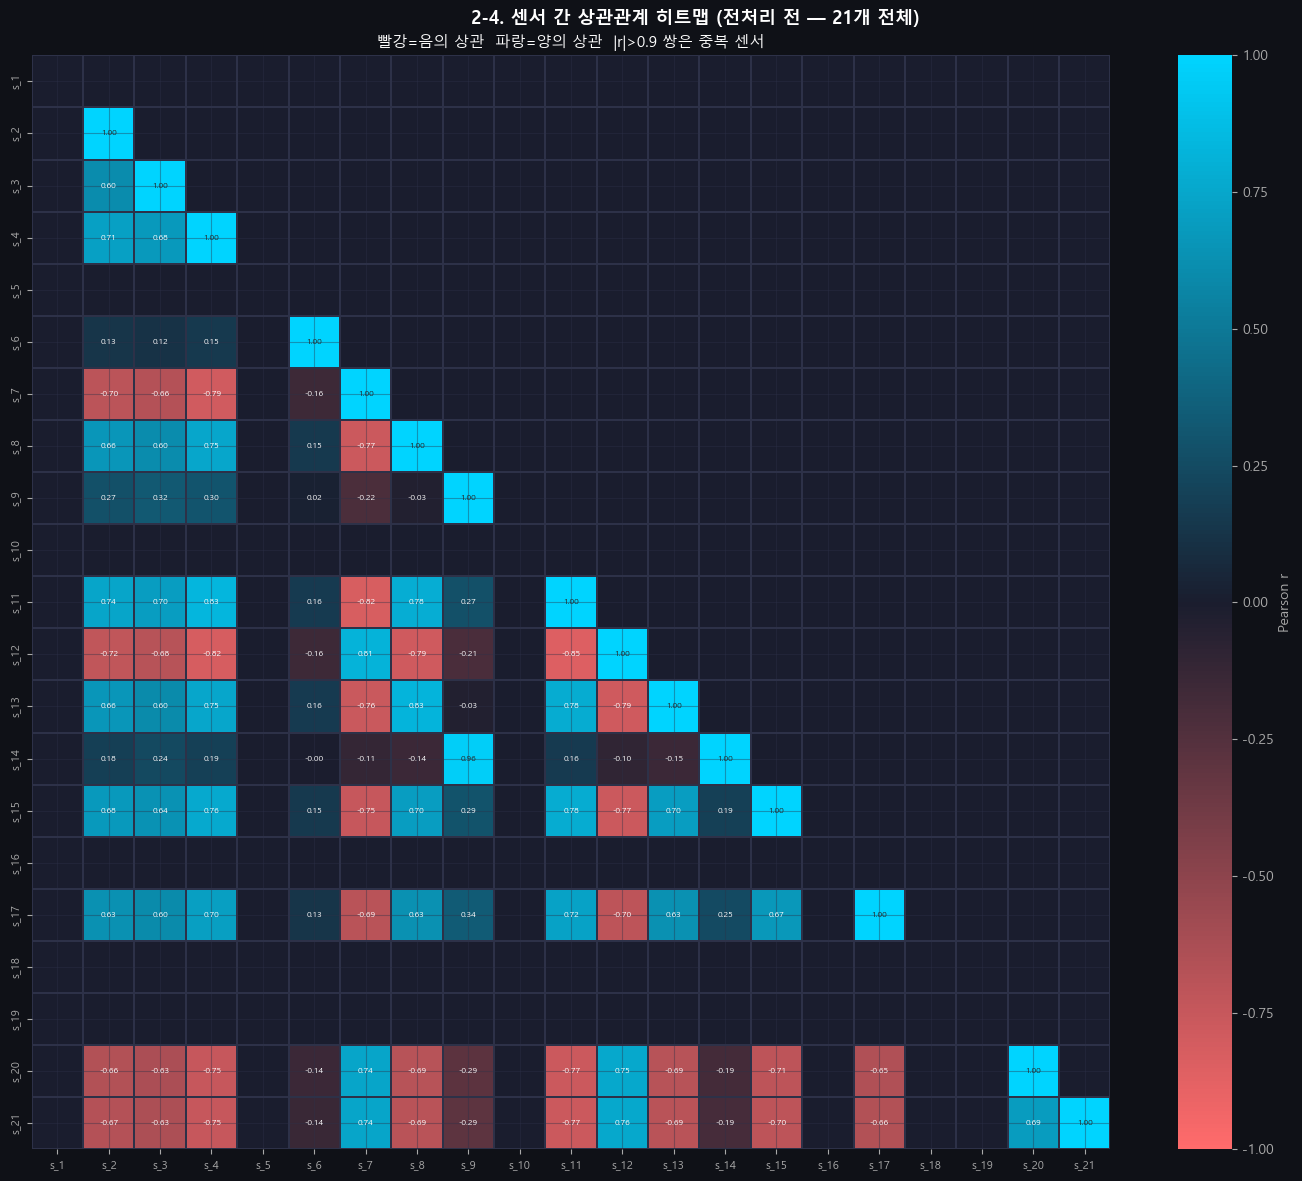

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_9,s_14,0.963


In [11]:
from matplotlib.colors import LinearSegmentedColormap

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# 고상관 쌍
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
if pairs:
    display(pd.DataFrame(pairs))
else:
    print('  해당 없음')

### 📊 2-4. 센서 간 상관관계 히트맵 결과

---

#### 히트맵 읽는 법
- **색상 의미**
  - 진한 파랑 (r → +1): 양의 상관 → 하나가 오르면 다른 것도 오름
  - 진한 빨강 (r → -1): 음의 상관 → 하나가 오르면 다른 것은 내림
  - 색 없음 (r → 0): 상관 없음 → 두 센서가 독립적으로 움직임
- **숫자**: 피어슨 상관계수 (-1 ~ +1)

---

#### 고상관 센서란?
- **|r| > 0.9** 인 센서 쌍 = 두 센서가 거의 같은 정보를 담고 있음
- 마치 같은 물리 현상을 두 개의 센서가 중복 측정하는 것
- 모델 입장에서 같은 정보가 두 번 들어오는 것 → 다중공선성 문제 가능성

---

#### 고상관 센서 쌍 결과

| 센서A | 센서B | r | 의미 |
|-------|-------|---|------|
| s_9 | s_14 | 0.963 | 거의 같은 정보 |

- s_9 = Nc 코어 속도(rpm)
- s_14 = NRc 보정 코어속도(rpm)
- NRc = NC / √(T입구 / T표준) → s_14는 s_9의 파생변수
- 즉 같은 물리 현상(코어 속도)을 다른 방식으로 측정한 것

---

#### 주요 상관관계 패턴

**양의 상관 (파랑)**
- s_2 ↔ s_3, s_4: 온도 센서들끼리 함께 상승
  → 엔진이 열화될수록 전체 온도가 같이 올라가는 현상

**음의 상관 (빨강)**
- s_7 ↔ s_2, s_3, s_4: 압력과 온도의 반대 관계
  → 온도 상승 시 압력 효율 하락
- s_20, s_21 ↔ s_2, s_3, s_4: 냉각 블리드와 온도의 반대 관계

---

#### 🔑 핵심 결론
> **고상관 쌍: s_9 ↔ s_14 (r=0.963)**
> → 둘 다 유지하면 같은 정보가 중복
> → 단, 논문 표준상 둘 다 유지하고 모델이 알아서 처리하도록 함
> → 추후 피처 중요도 분석에서 재검토 예정

> **상수 센서(s_1, s_5, s_10, s_16, s_18, s_19)는**
> 히트맵에서 색이 없는 구간으로 나타남
> → 다른 센서와 상관관계 자체가 없음 = 제거 근거 재확인

### 2-5. 센서별 열화 트렌드 (전처리 전)

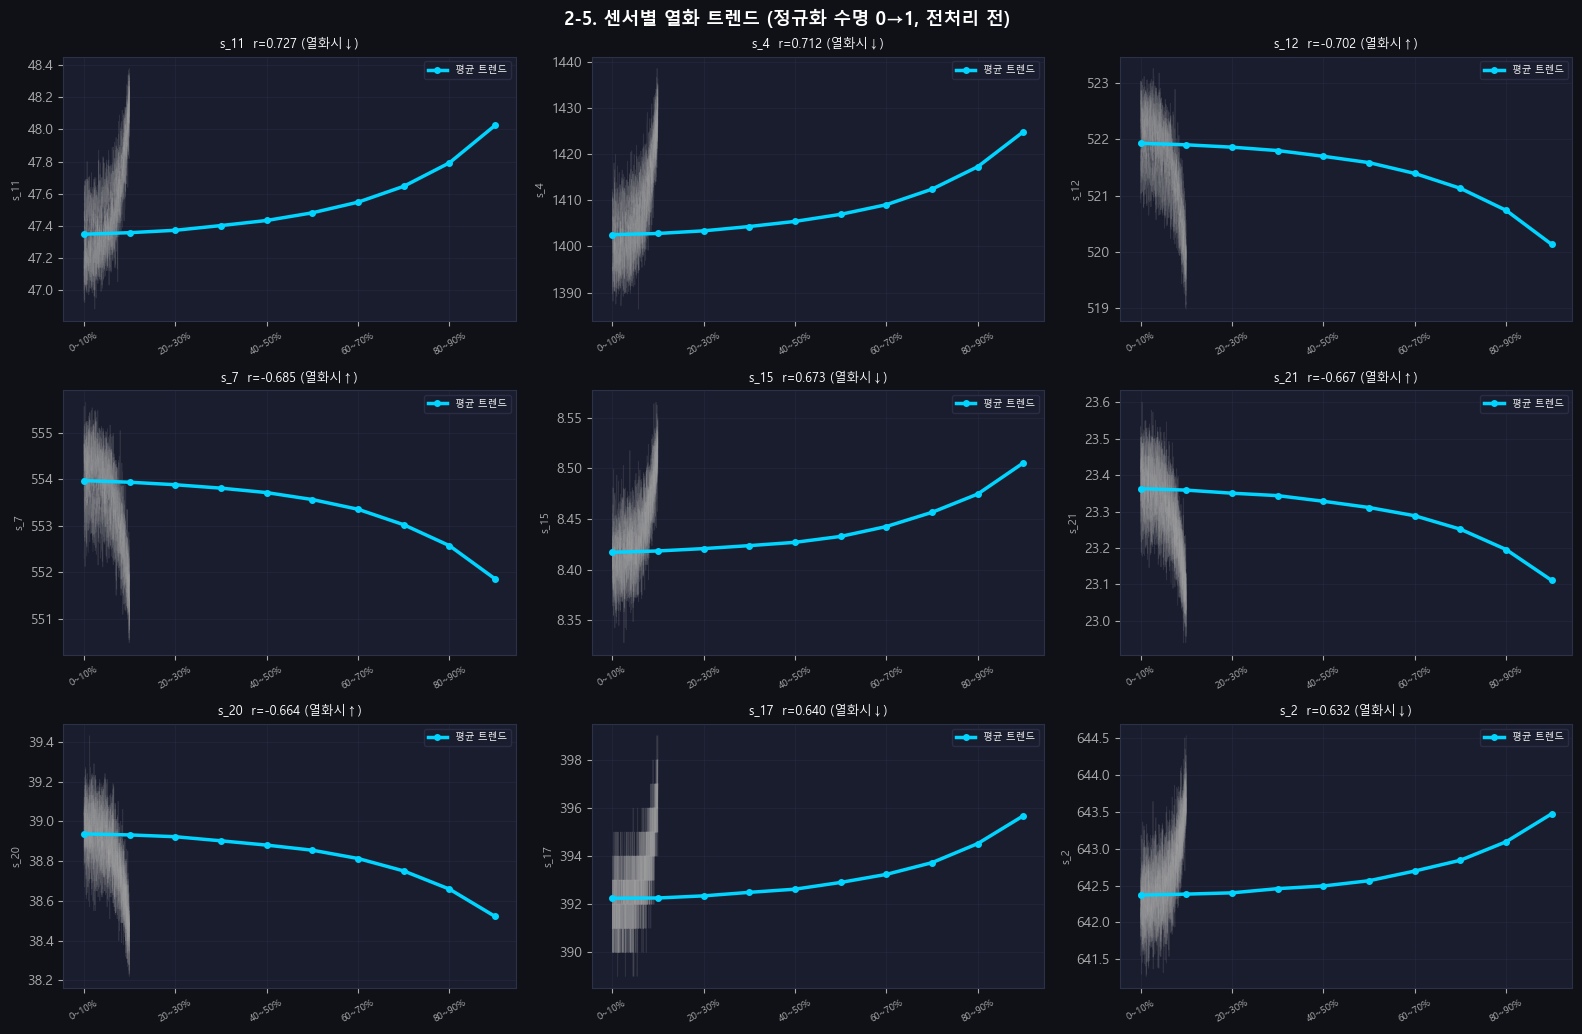

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [12]:
# 정규화 수명축(0=새것, 1=고장 직전)으로 평균 트렌드 확인
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 유의미한 트렌드 센서만 표시 (|corr|>0.1)
corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.1].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]  # 최대 9개

n_cols = 3
n_rows = (len(trend_sensors)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

x_pos = range(len(labels))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes.flat, trend_sensors):
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
    r = corr_with_life[s]
    direction = '열화시↑' if r<0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8)
    ax.legend(fontsize=7)

for ax in axes.flat[len(trend_sensors):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')

### 📊 2-5. 센서별 열화 트렌드 결과

---

#### 그래프 읽는 법
- x축: 정규화 수명 (0~10% = 새 엔진 → 90~100% = 고장 직전)
- y축: 센서값
- 회색 선: 개별 엔진 15개 샘플
- 파란 선: 전체 평균 트렌드
- r < 0: 열화시 센서값 증가 (↑)
- r > 0: 열화시 센서값 감소 (↓)

---

#### 센서별 트렌드 분류

**열화시 증가하는 센서 (r < 0)**
| 센서 | r | 의미 |
|------|---|------|
| s_12 | -0.702 | 연료/압력 비율 상승 → 연료 효율 저하 |
| s_7  | -0.685 | HPC 출구 압력 상승 → 압축기 과부하 |
| s_20 | -0.664 | HPT 냉각블리드 상승 → 냉각 필요 증가 |

**열화시 감소하는 센서 (r > 0)**
| 센서 | r | 의미 |
|------|---|------|
| s_11 | 0.727 | 정적압력 감소 → 압력 손실 증가 |
| s_4  | 0.712 | LPT 출구 온도 감소 → 터빈 효율 저하 |
| s_15 | 0.673 | 바이패스 비율 감소 → 엔진 효율 저하 |
| s_21 | 0.667 | LPT 냉각블리드 감소 |
| s_17 | 0.640 | 블리드 엔탈피 감소 |
| s_2  | 0.632 | LPC 출구 온도 감소 |

---

#### 🔑 핵심 포인트

**① 초반 구간(0~20%) 패턴**
- 모든 센서에서 초반에 회색 선이 좁게 뭉쳐있음
- 정상 운전 구간 → 센서값이 안정적
- Cap=125 설정 근거 재확인
  → 이 구간은 RUL 예측에 의미 없음

**② 후반 구간(80~100%) 패턴**
- 평균 트렌드(파란 선)가 급격히 변화
- 열화가 가속되는 구간
- 이 구간의 패턴 학습이 RUL 예측의 핵심

**③ 대응 표본 t검정 근거**
- 수명 80% 전후로 센서값이 눈에 띄게 달라짐
- → 통계적으로 유의미한 차이인지 검정 예정

### 2-6. RUL 상관계수 (전처리 전)

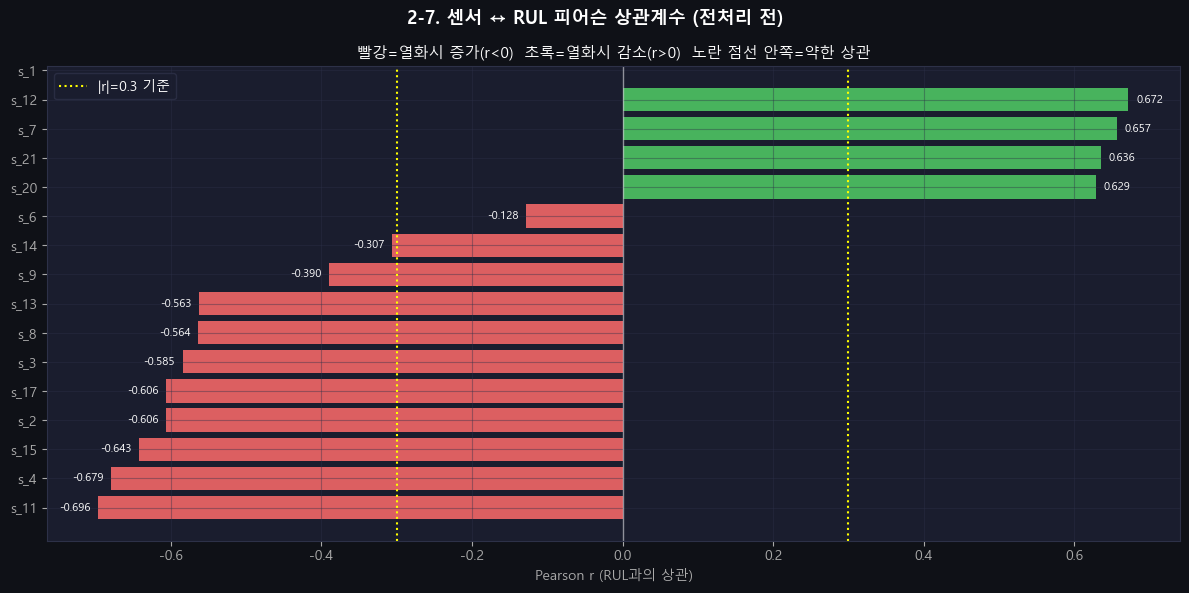

|r|>0.3 고상관 센서: 14개
  s_11: r=-0.696  Ps30 정적압력(psia)
  s_4: r=-0.679  T50 LPT 출구 온도(°R)
  s_12: r=0.672  phi 연료/Ps30 비율
  s_7: r=0.657  P30 HPC 출구 압력(psia)
  s_15: r=-0.643  BPR 바이패스 비율
  s_21: r=0.636  W32 LPT 냉각블리드
  s_20: r=0.629  W31 HPT 냉각블리드
  s_2: r=-0.606  T24 LPC 출구 온도(°R)
  s_17: r=-0.606  htBleed 블리드 엔탈피
  s_3: r=-0.585  T30 HPC 출구 온도(°R)
  s_8: r=-0.564  Nf 팬 속도(rpm)
  s_13: r=-0.563  NRf 보정 팬 속도(rpm)
  s_9: r=-0.390  Nc 코어 속도(rpm)
  s_14: r=-0.307  NRc 보정 코어속도(rpm)


In [14]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-7. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')

### 📊 2-7. 센서 ↔ RUL 피어슨 상관계수 결과 (전처리 전)

---

#### 그래프 읽는 법
- **빨간 막대 (r < 0):** 열화시 센서값 증가
  → RUL이 줄어들수록(고장 가까울수록) 센서값이 올라감
- **초록 막대 (r > 0):** 열화시 센서값 감소
  → RUL이 줄어들수록 센서값이 내려감
- **노란 점선 (|r| = 0.3):** 이 안쪽은 RUL과 상관이 약한 센서

---

#### 고상관 센서 (|r| > 0.3) — 총 14개

**열화시 증가하는 센서 (빨간 막대)**
| 센서 | r | 물리적 의미 |
|------|---|------------|
| s_11 | -0.696 | Ps30 정적압력 → 열화시 압력 상승 |
| s_4  | -0.679 | T50 LPT 출구 온도 → 열화시 온도 상승 |
| s_15 | -0.643 | BPR 바이패스 비율 → 열화시 증가 |
| s_2  | -0.606 | T24 LPC 출구 온도 → 열화시 온도 상승 |
| s_17 | -0.606 | htBleed 블리드 엔탈피 → 열화시 증가 |
| s_3  | -0.585 | T30 HPC 출구 온도 → 열화시 온도 상승 |
| s_8  | -0.564 | Nf 팬 속도 → 열화시 증가 |
| s_13 | -0.563 | NRf 보정 팬 속도 → 열화시 증가 |
| s_9  | -0.390 | Nc 코어 속도 → 열화시 증가 |
| s_14 | -0.307 | NRc 보정 코어속도 → 열화시 증가 |

**열화시 감소하는 센서 (초록 막대)**
| 센서 | r | 물리적 의미 |
|------|---|------------|
| s_12 | 0.672 | phi 연료/Ps30 비율 → 열화시 감소 |
| s_7  | 0.657 | P30 HPC 출구 압력 → 열화시 압력 감소 |
| s_21 | 0.636 | W32 LPT 냉각블리드 → 열화시 감소 |
| s_20 | 0.629 | W31 HPT 냉각블리드 → 열화시 감소 |

---

#### 🔑 핵심 결론

**① 상수 센서는 상관계수가 거의 0**
- s_1, s_5, s_6, s_10, s_16, s_18, s_19
- → 제거 근거 재확인 ✅

**② 유용 센서 14개 전부 |r| > 0.3**
- 모두 RUL과 유의미한 상관관계
- → 14개 센서 전부 모델 입력으로 사용 근거 ✅

**③ s_9, s_14 상관계수가 상대적으로 낮음**
- s_9: r=-0.390, s_14: r=-0.307
- 다른 센서 대비 RUL과의 직접 상관이 약함
- 단, 고상관 쌍(r=0.963)이므로 중복 정보 포함
- → 추후 피처 중요도 분석에서 재검토 예정

> 💡 다음 단계: 스피어만 상관계수, Mann-Kendall,
> 대응 표본 t검정으로 통계적 유의성 검증 예정

### 3. 통계 검정

---

#### 검정 목적
EDA에서 시각적으로 확인한 패턴들을 **통계적으로 증명**하는 단계

| 검정 | 목적 |
|------|------|
| 3-1. 시차 상관관계 (Lag Correlation) | 몇 사이클 전 센서값이 RUL과 가장 연관있는지 확인 → 슬라이딩 윈도우 크기(30) 근거 |
| 3-2. Mann-Kendall | 센서값의 열화 트렌드가 통계적으로 유의미한지 검정 |
| 3-3. 대응 표본 t검정 | 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정 |

---

#### 가설

**3-1. 시차 상관관계**
- H₀: 과거 센서값과 현재 RUL 사이에 상관관계가 없다
- H₁: 특정 시차(lag)에서 센서값과 RUL 사이에 유의미한 상관관계가 있다

**3-2. Mann-Kendall**
- H₀: 센서값에 단조 트렌드가 없다 (랜덤하게 변한다)
- H₁: 센서값에 유의미한 단조 트렌드가 있다 (열화 신호 존재)

**3-3. 대응 표본 t검정**
- H₀: 수명 80% 이전과 이후 구간의 센서 평균에 차이가 없다
- H₁: 수명 80% 이후 구간에서 센서 평균이 유의미하게 달라진다

> 💡 모든 검정의 유의수준: α = 0.05
> p-value < 0.05 → H₀ 기각 → H₁ 채택

=== 3-1. 시차 상관관계 (Lag Correlation) ===


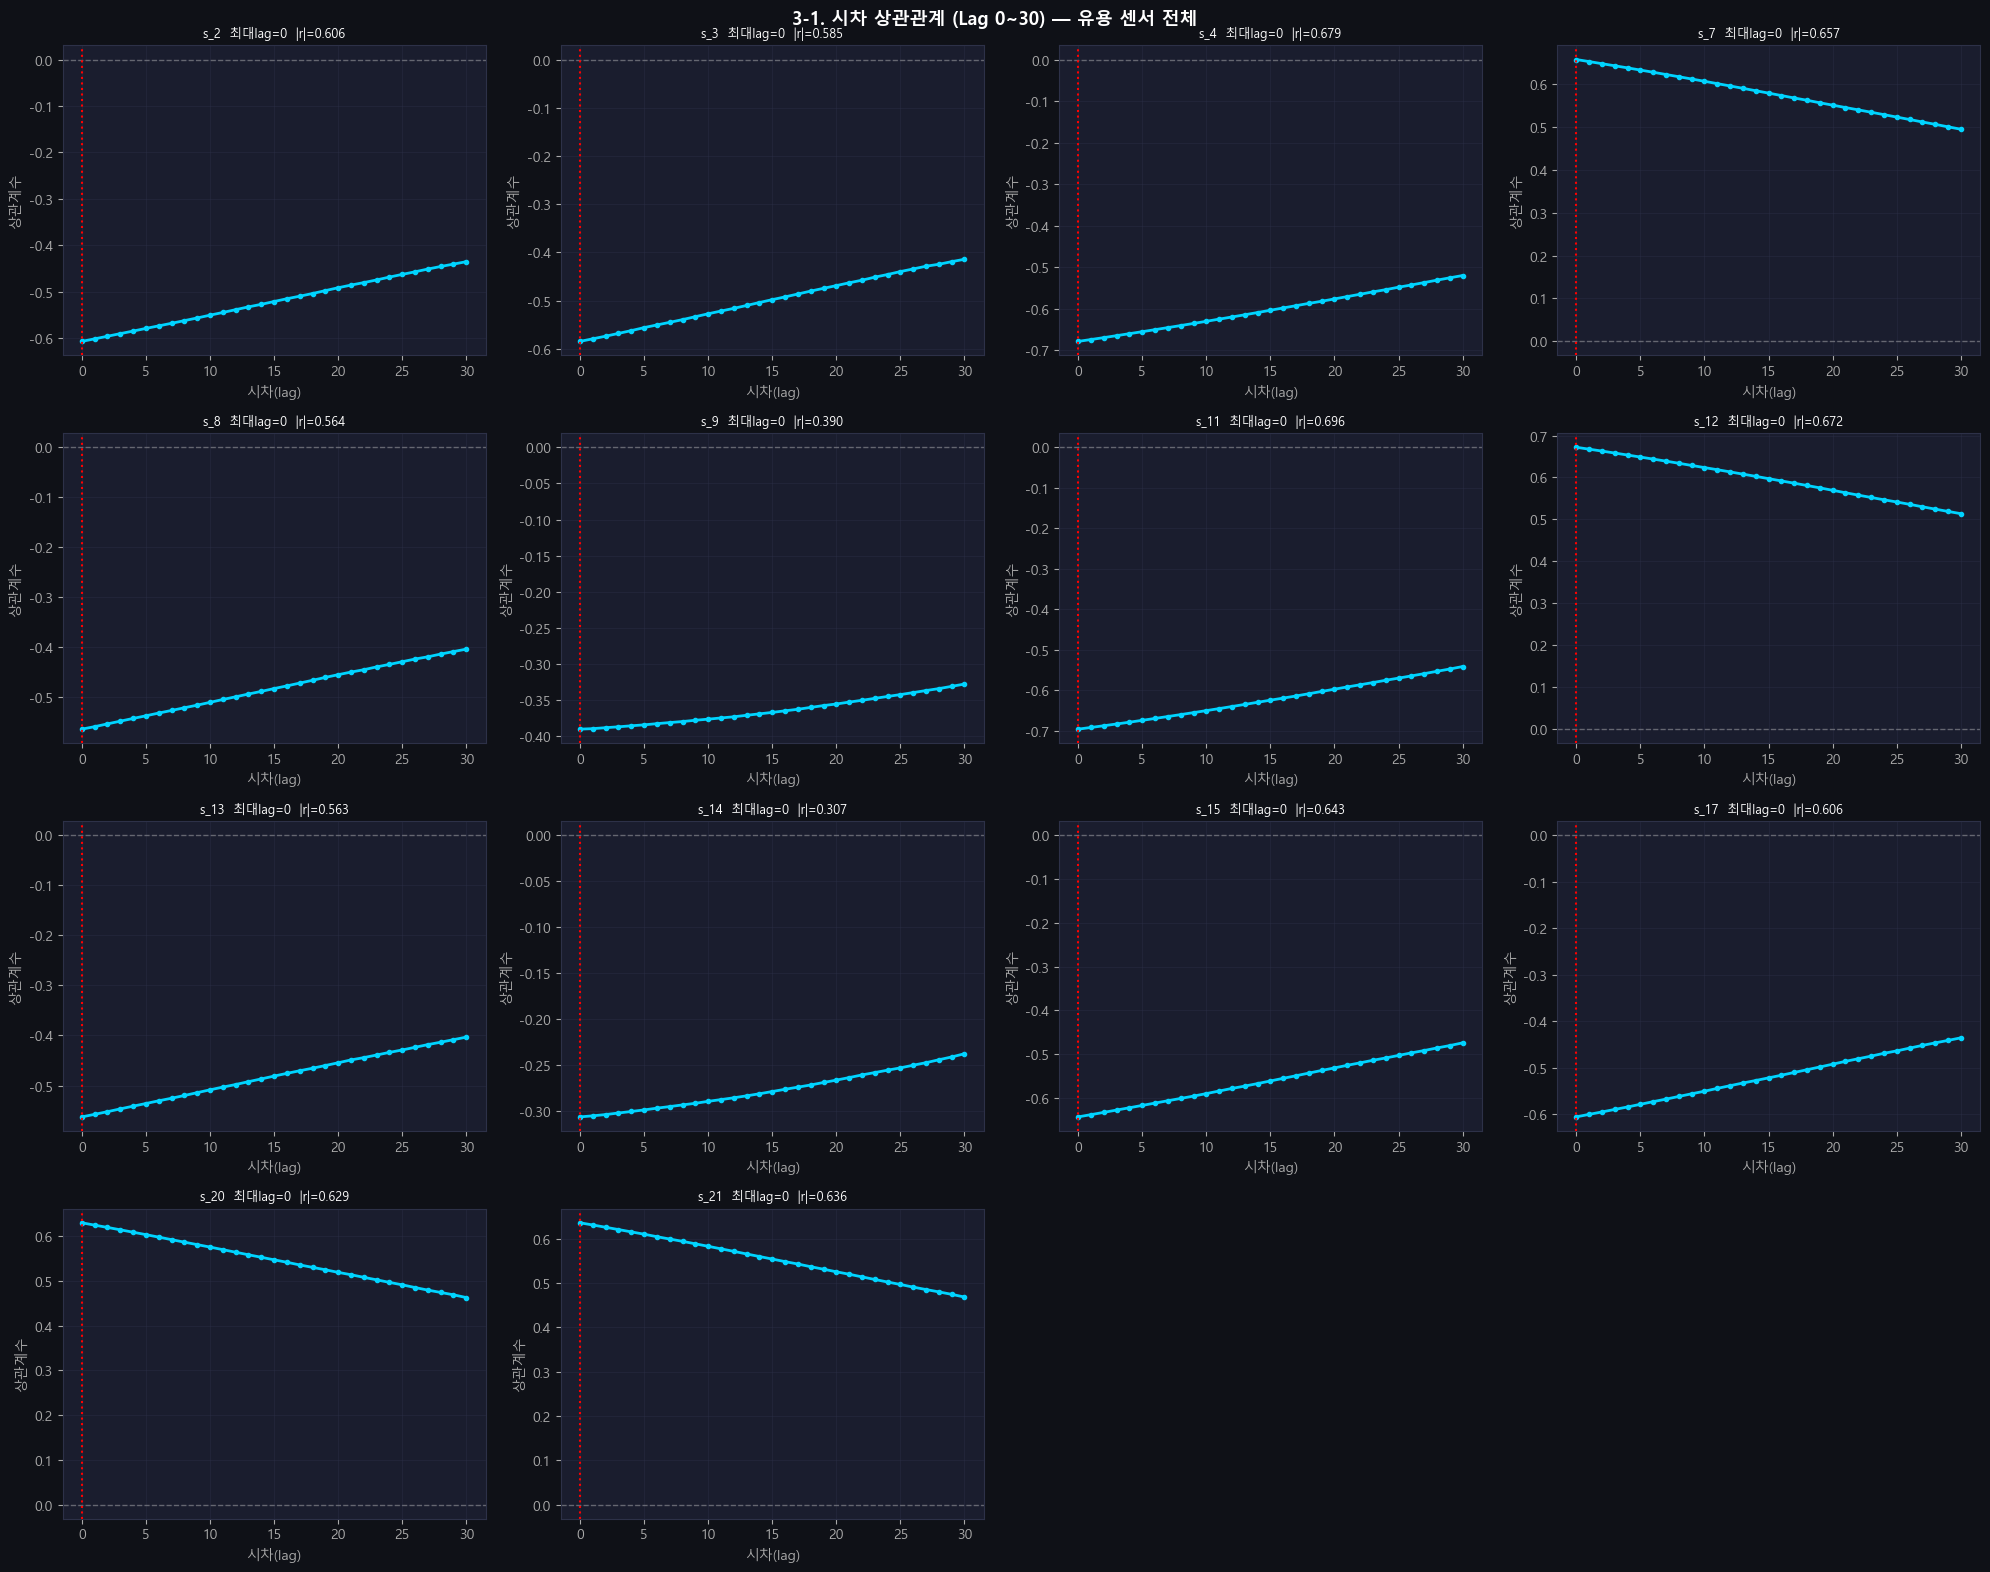


=== 센서별 최적 시차 요약 ===
  s_2: lag=0사이클에서 최대 상관 (r=-0.606)
  s_3: lag=0사이클에서 최대 상관 (r=-0.585)
  s_4: lag=0사이클에서 최대 상관 (r=-0.679)
  s_7: lag=0사이클에서 최대 상관 (r=0.657)
  s_8: lag=0사이클에서 최대 상관 (r=-0.564)
  s_9: lag=0사이클에서 최대 상관 (r=-0.390)
  s_11: lag=0사이클에서 최대 상관 (r=-0.696)
  s_12: lag=0사이클에서 최대 상관 (r=0.672)
  s_13: lag=0사이클에서 최대 상관 (r=-0.563)
  s_14: lag=0사이클에서 최대 상관 (r=-0.307)
  s_15: lag=0사이클에서 최대 상관 (r=-0.643)
  s_17: lag=0사이클에서 최대 상관 (r=-0.606)
  s_20: lag=0사이클에서 최대 상관 (r=0.629)
  s_21: lag=0사이클에서 최대 상관 (r=0.636)


In [15]:
# 3-1. 시차 상관관계 (Lag Correlation)
print('=== 3-1. 시차 상관관계 (Lag Correlation) ===')

tr_lag = train_raw.copy()
mc = tr_lag.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_lag = tr_lag.join(mc, on='unit_nr')
tr_lag['RUL'] = tr_lag['max_c'] - tr_lag['time_cycles']

# 유용 센서만 (상수 센서 제외)
useful_sensors = [s for s in SENSOR_COLS 
                  if train_raw[s].std() >= CONST_THR]

max_lag = 30  # 슬라이딩 윈도우 크기와 동일
lag_results = {}

for s in useful_sensors:
    lag_corrs = []
    for lag in range(0, max_lag + 1):
        shifted = tr_lag.groupby('unit_nr')[s].shift(lag)
        valid = ~shifted.isna()
        r = tr_lag.loc[valid, 'RUL'].corr(shifted[valid])
        lag_corrs.append(r)
    lag_results[s] = lag_corrs

# 시각화
n_cols = 4
n_rows = (len(useful_sensors) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('3-1. 시차 상관관계 (Lag 0~30) — 유용 센서 전체', 
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, useful_sensors):
    lag_corrs = lag_results[s]
    best_lag = int(np.argmax(np.abs(lag_corrs)))
    best_r   = lag_corrs[best_lag]
    ax.plot(range(max_lag + 1), lag_corrs, 
            color=C[0], lw=2, marker='o', markersize=3)
    ax.axhline(0, color=GRAY, ls='--', lw=1, alpha=0.5)
    ax.axvline(best_lag, color='red', ls=':', lw=1.5)
    ax.set_title(f'{s}  최대lag={best_lag}  |r|={abs(best_r):.3f}', fontsize=9)
    ax.set_xlabel('시차(lag)')
    ax.set_ylabel('상관계수')

for ax in axes.flat[len(useful_sensors):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# 결과 요약
print('\n=== 센서별 최적 시차 요약 ===')
for s in useful_sensors:
    best_lag = int(np.argmax(np.abs(lag_results[s])))
    best_r   = lag_results[s][best_lag]
    print(f'  {s}: lag={best_lag}사이클에서 최대 상관 (r={best_r:.3f})')

### 📊 3-1. 시차 상관관계 결과

---

#### 상관계수 방향 해석
- **r < 0 (음의 상관):** RUL이 줄어들수록 센서값이 올라감
  → 고장에 가까워질수록 센서값 증가
- **r > 0 (양의 상관):** RUL이 줄어들수록 센서값도 내려감
  → 고장에 가까워질수록 센서값 감소

---

#### 결과 해석
- **모든 센서에서 lag=0이 최대 상관**
- lag가 커질수록 상관계수가 점점 약해지는 패턴

---

#### 센서별 최적 시차 요약

| 센서 | 최적 lag | r | 방향 |
|------|---------|---|------|
| s_11 | 0 | -0.696 | RUL 감소 → 센서값 증가↑ |
| s_4  | 0 | -0.679 | RUL 감소 → 센서값 증가↑ |
| s_15 | 0 | -0.643 | RUL 감소 → 센서값 증가↑ |
| s_2  | 0 | -0.606 | RUL 감소 → 센서값 증가↑ |
| s_17 | 0 | -0.606 | RUL 감소 → 센서값 증가↑ |
| s_3  | 0 | -0.585 | RUL 감소 → 센서값 증가↑ |
| s_8  | 0 | -0.564 | RUL 감소 → 센서값 증가↑ |
| s_13 | 0 | -0.563 | RUL 감소 → 센서값 증가↑ |
| s_9  | 0 | -0.390 | RUL 감소 → 센서값 증가↑ |
| s_14 | 0 | -0.307 | RUL 감소 → 센서값 증가↑ |
| s_12 | 0 | 0.672 | RUL 감소 → 센서값 감소↓ |
| s_7  | 0 | 0.657 | RUL 감소 → 센서값 감소↓ |
| s_21 | 0 | 0.636 | RUL 감소 → 센서값 감소↓ |
| s_20 | 0 | 0.629 | RUL 감소 → 센서값 감소↓ |

---

#### 🔑 핵심 결론

**① 모든 센서 lag=0에서 최대 상관**
- 과거 값보다 현재 값이 RUL을 가장 잘 설명함
- 센서가 열화를 실시간으로 반영하고 있다는 의미

**② lag가 커질수록 상관이 약해짐**
- 그러나 lag=30까지도 상관관계가 유지됨
- → 과거 30사이클치 데이터가 여전히 유효한 정보를 담고 있음
- → **슬라이딩 윈도우 크기 30 설정의 근거** ✅

**③ H₁ 채택**
- 모든 센서에서 lag=0 기준 유의미한 상관관계 확인
- → 과거 센서값과 현재 RUL 사이에 상관관계가 존재함
- → H₀ 기각: 과거 센서값과 현재 RUL 사이에 상관관계가 없다 ❌

---
### 3-2. Mann-Kendall 트렌드 검정

---

#### 검정 목적
센서값이 시간에 따라 단조롭게 증가 또는 감소하는 트렌드가
통계적으로 유의미한지 검정

---

#### 트렌드란?
시간이 지남에 따라 전체적으로 한 방향으로 변하는 경향
오르락내리락 해도 전체적인 방향성이 있으면 트렌드 있음

**트렌드 있음 (우상향)**
- 사이클:  1    2    3    4    5    6    7
- 센서값: 100  102   99  103  101  105  104
- → 오르락내리락 하지만 전체적으로 증가

**트렌드 없음 (방향성 없음)**
- 사이클:  1    2    3    4    5    6    7
- 센서값: 100  103   98  105   99  102  101
- → 오르락내리락 하고 방향성 없음 (노이즈)

---

#### 우리 데이터에서 의미
- **트렌드 있음** → 엔진이 닳아갈수록 센서값이 체계적으로 변함
  → 열화 정보를 담고 있음 → RUL 예측에 유효한 센서 ✅
- **트렌드 없음** → 센서값이 랜덤하게 움직이는 것
  → 열화 정보를 담고 있지 않음 → RUL 예측에 기여 못함 ❌

---

#### 가설
- H₀: 센서값에 단조 트렌드가 없다 (랜덤하게 변한다)
- H₁: 센서값에 유의미한 단조 트렌드가 있다 (열화 신호 존재)

> 💡 유의수준: α = 0.05
> p-value < 0.05 → H₀ 기각 → 트렌드 존재 통계적 증명

---

#### 켄달 타우(τ) 해석
- τ > 0: 시간이 지날수록 센서값 증가
- τ < 0: 시간이 지날수록 센서값 감소
- **|τ| 클수록 트렌드가 강함**

=== 3-2. Mann-Kendall 트렌드 검정 ===
목적: 센서값에 유의미한 단조 트렌드가 있는지 검정
대상: 엔진 #1 기준



,켄달 타우(τ),p-value,트렌드 방향,판정
센서,,,,
s_12,-0.6509,0.0,감소↓,트렌드 있음✅
s_7,-0.5937,0.0,감소↓,트렌드 있음✅
s_21,-0.5720,0.0,감소↓,트렌드 있음✅
s_20,-0.5315,0.0,감소↓,트렌드 있음✅
s_14,-0.5057,0.0,감소↓,트렌드 있음✅
s_9,-0.2893,0.0,감소↓,트렌드 있음✅
s_3,0.3934,0.0,증가↑,트렌드 있음✅
s_2,0.4958,0.0,증가↑,트렌드 있음✅
s_15,0.5134,0.0,증가↑,트렌드 있음✅


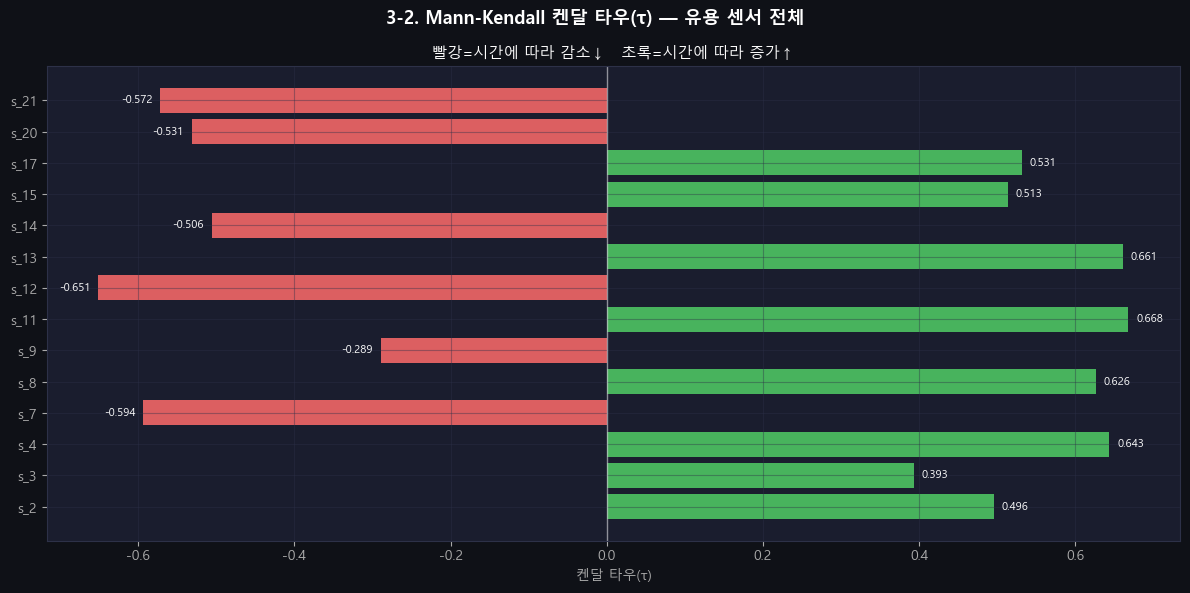


트렌드 있는 센서 (p<0.05): 14/14개


In [16]:
# 3-2. Mann-Kendall 트렌드 검정
from scipy.stats import kendalltau

print('=== 3-2. Mann-Kendall 트렌드 검정 ===')
print('목적: 센서값에 유의미한 단조 트렌드가 있는지 검정')
print('대상: 엔진 #1 기준')
print()

unit1 = train_raw[train_raw['unit_nr'] == 1].sort_values('time_cycles')

mk_rows = []
for s in useful_sensors:
    arr = unit1[s].values
    # 시간 인덱스와 센서값의 켄달 타우 계산
    time_idx = np.arange(len(arr))
    tau, p_val = kendalltau(time_idx, arr)
    mk_rows.append({
        '센서': s,
        '켄달 타우(τ)': round(tau, 4),
        'p-value': round(p_val, 4),
        '트렌드 방향': '증가↑' if tau > 0 else '감소↓',
        '판정': '트렌드 있음✅' if p_val < 0.05 else '트렌드 없음⚠️'
    })

mk_df = pd.DataFrame(mk_rows).set_index('센서')
display(mk_df.sort_values('켄달 타우(τ)'))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('3-2. Mann-Kendall 켄달 타우(τ) — 유용 센서 전체', 
             fontsize=13, fontweight='bold')

colors = [C[1] if v < 0 else C[2] for v in mk_df['켄달 타우(τ)']]
bars = ax.barh(mk_df.index, mk_df['켄달 타우(τ)'], color=colors, alpha=0.85)
ax.axvline(0, color='white', lw=1, alpha=0.5)
ax.set_xlabel('켄달 타우(τ)')
ax.set_title('빨강=시간에 따라 감소↓   초록=시간에 따라 증가↑')
for bar, val in zip(bars, mk_df['켄달 타우(τ)']):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

n_trend = (mk_df['p-value'] < 0.05).sum()
print(f'\n트렌드 있는 센서 (p<0.05): {n_trend}/{len(mk_df)}개')

### 📊 3-2. Mann-Kendall 트렌드 검정 결과

---

#### 결과 요약

| 항목 | 결과 |
|------|------|
| 검정 대상 | 유용 센서 14개 (엔진 #1 기준) |
| 트렌드 있는 센서 | **14/14개** |
| 모든 p-value | 0.0 (< 0.05) |

---

#### 센서별 결과

**시간에 따라 감소하는 센서 (τ < 0)**
| 센서 | τ | 의미 |
|------|---|------|
| s_12 | -0.651 | 열화될수록 연료/압력 비율 감소 |
| s_7  | -0.594 | 열화될수록 HPC 출구 압력 감소 |
| s_21 | -0.572 | 열화될수록 LPT 냉각블리드 감소 |
| s_20 | -0.531 | 열화될수록 HPT 냉각블리드 감소 |
| s_14 | -0.506 | 열화될수록 보정 코어속도 감소 |
| s_9  | -0.289 | 열화될수록 코어 속도 감소 |

**시간에 따라 증가하는 센서 (τ > 0)**
| 센서 | τ | 의미 |
|------|---|------|
| s_11 | 0.668 | 열화될수록 정적압력 증가 |
| s_13 | 0.661 | 열화될수록 보정 팬 속도 증가 |
| s_4  | 0.643 | 열화될수록 LPT 출구 온도 증가 |
| s_8  | 0.626 | 열화될수록 팬 속도 증가 |
| s_17 | 0.531 | 열화될수록 블리드 엔탈피 증가 |
| s_15 | 0.513 | 열화될수록 바이패스 비율 증가 |
| s_2  | 0.496 | 열화될수록 LPC 출구 온도 증가 |
| s_3  | 0.393 | 열화될수록 HPC 출구 온도 증가 |

---

#### 🔑 핵심 결론

**① H₁ 채택 — 14/14개 센서 모두 트렌드 존재**
- 모든 p-value = 0.0 (< 0.05)
- → H₀ 기각: 센서값에 단조 트렌드가 없다 ❌
- → H₁ 채택: 센서값에 유의미한 단조 트렌드가 있다 ✅

**② 물리적 해석**
- 온도 관련 센서(s_2, s_3, s_4): 열화될수록 증가
  → 엔진 효율 저하로 열이 더 많이 발생
- 속도/압력 관련 센서(s_7, s_9, s_12): 열화될수록 감소
  → 부품 마모로 압력과 속도가 떨어짐

**③ 다음 단계 근거**
- 14개 센서 모두 열화 트렌드 통계적 증명
- → 14개 센서 전부 모델 입력으로 사용 확정 ✅
- → 대응 표본 t검정으로 수명 20% 전후 차이 추가 검증 예정

### 3-3. 대응 표본 t검정 (Paired t-test)

---

#### 검정 목적
EDA에서 시각적으로 확인한
**잔여 수명이 20% 남은 시점부터 센서값이 급격히 변화하는 패턴**을
통계적으로 증명

---

#### 대응 표본이란?
- 동일한 대상(엔진)을 두 가지 조건(전/후)에서 측정한 것
- 예: 엔진 1번의 수명 80% 이전 평균 vs 마지막 20% 구간 평균
- 100개 엔진 = 100쌍의 대응 표본

---

#### 왜 마지막 20% 시점인가?
- EDA 열화 트렌드 시각화에서
  수명이 20% 남은 시점부터
  평균 트렌드가 급격히 변화하는 것을 시각적으로 확인
- 이 구간이 실제로 엔진 상태가 급격히 나빠지는 구간인지
  통계적으로 검증

---

#### 가설
- H₀: 수명 80% 이전 구간과 마지막 20% 구간의 센서 평균에 차이가 없다
- H₁: 마지막 20% 구간에서 센서 평균이 유의미하게 달라진다
  → 즉 잔여 수명 20% 시점부터 엔진 상태가 급격히 변한다

> 💡 유의수준: α = 0.05
> p-value < 0.05 → H₀ 기각 → 마지막 20% 구간에서
> 유의미한 센서값 변화 통계적 증명

=== 3-3. 대응 표본 t검정 ===
목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정



,t통계량,p-value,변화 방향,판정
센서,,,,
s_15,-60.4602,0.0,증가↑,차이 있음✅
s_17,-58.2407,0.0,증가↑,차이 있음✅
s_4,-58.2152,0.0,증가↑,차이 있음✅
s_3,-56.7932,0.0,증가↑,차이 있음✅
s_2,-55.7754,0.0,증가↑,차이 있음✅
s_11,-54.1168,0.0,증가↑,차이 있음✅
s_8,-23.3983,0.0,증가↑,차이 있음✅
s_13,-23.1932,0.0,증가↑,차이 있음✅
s_9,-7.8896,0.0,증가↑,차이 있음✅


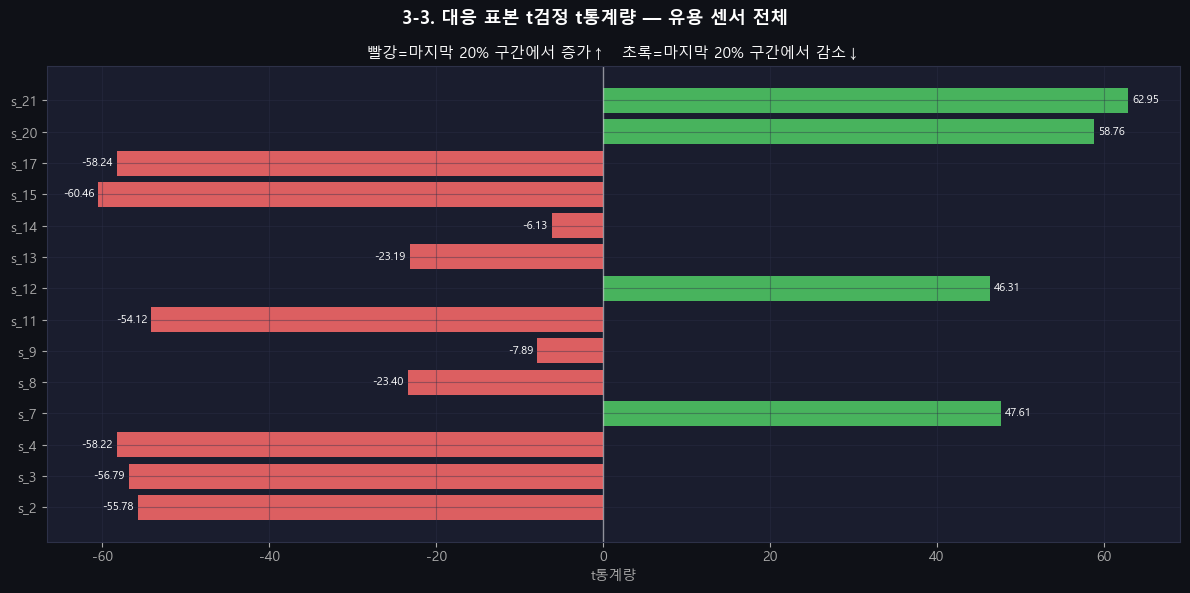


유의미한 차이 있는 센서 (p<0.05): 14/14개


In [17]:
# 3-3. 대응 표본 t검정
from scipy.stats import ttest_rel

print('=== 3-3. 대응 표본 t검정 ===')
print('목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정')
print()

ttest_rows = []
for s in useful_sensors:
    before_means = []
    after_means  = []

    for unit in train_raw['unit_nr'].unique():
        sub = train_raw[train_raw['unit_nr'] == unit].sort_values('time_cycles')
        max_cycle = sub['time_cycles'].max()
        threshold = max_cycle * 0.8  # 수명 80% 시점 = 잔여 20% 시작점

        # 수명 80% 이전 (정상 구간)
        before = sub[sub['time_cycles'] <= threshold][s].mean()
        # 마지막 20% 구간 (열화 가속 구간)
        after  = sub[sub['time_cycles'] >  threshold][s].mean()

        before_means.append(before)
        after_means.append(after)

    t_stat, p_val = ttest_rel(before_means, after_means)
    ttest_rows.append({
        '센서'      : s,
        't통계량'   : round(t_stat, 4),
        'p-value'   : round(p_val, 4),
        '변화 방향' : '증가↑' if t_stat < 0 else '감소↓',
        '판정'      : '차이 있음✅' if p_val < 0.05 else '차이 없음⚠️'
    })

ttest_df = pd.DataFrame(ttest_rows).set_index('센서')
display(ttest_df.sort_values('t통계량'))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('3-3. 대응 표본 t검정 t통계량 — 유용 센서 전체',
             fontsize=13, fontweight='bold')

colors = [C[1] if v < 0 else C[2] for v in ttest_df['t통계량']]
bars = ax.barh(ttest_df.index, ttest_df['t통계량'], color=colors, alpha=0.85)
ax.axvline(0, color='white', lw=1, alpha=0.5)
ax.set_xlabel('t통계량')
ax.set_title('빨강=마지막 20% 구간에서 증가↑   초록=마지막 20% 구간에서 감소↓')
for bar, val in zip(bars, ttest_df['t통계량']):
    ax.text(val + (0.5 if val >= 0 else -0.5),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

n_sig = (ttest_df['p-value'] < 0.05).sum()
print(f'\n유의미한 차이 있는 센서 (p<0.05): {n_sig}/{len(ttest_df)}개')

### 📊 3-3. 대응 표본 t검정 결과

---

#### 결과 요약

| 항목 | 결과 |
|------|------|
| 검정 대상 | 유용 센서 14개 |
| 유의미한 차이 있는 센서 | **14/14개** |
| 모든 p-value | 0.0 (< 0.05) |

---

#### 센서별 결과

**마지막 20% 구간에서 증가하는 센서 (t < 0)**
| 센서 | t통계량 | 의미 |
|------|--------|------|
| s_15 | -60.46 | 잔여 수명 20%부터 바이패스 비율 급증 |
| s_17 | -58.24 | 잔여 수명 20%부터 블리드 엔탈피 급증 |
| s_4  | -58.22 | 잔여 수명 20%부터 LPT 출구 온도 급증 |
| s_3  | -56.79 | 잔여 수명 20%부터 HPC 출구 온도 급증 |
| s_2  | -55.78 | 잔여 수명 20%부터 LPC 출구 온도 급증 |
| s_11 | -54.12 | 잔여 수명 20%부터 정적압력 급증 |
| s_8  | -23.40 | 잔여 수명 20%부터 팬 속도 급증 |
| s_13 | -23.19 | 잔여 수명 20%부터 보정 팬 속도 급증 |
| s_9  | -7.89  | 잔여 수명 20%부터 코어 속도 급증 |
| s_14 | -6.13  | 잔여 수명 20%부터 보정 코어속도 급증 |

**마지막 20% 구간에서 감소하는 센서 (t > 0)**
| 센서 | t통계량 | 의미 |
|------|--------|------|
| s_21 | 62.95 | 잔여 수명 20%부터 LPT 냉각블리드 급감 |
| s_20 | 58.76 | 잔여 수명 20%부터 HPT 냉각블리드 급감 |
| s_7  | 47.61 | 잔여 수명 20%부터 HPC 출구 압력 급감 |
| s_12 | 46.31 | 잔여 수명 20%부터 연료/압력 비율 급감 |

---

#### 🔑 핵심 결론

**① H₁ 채택 — 14/14개 센서 모두 유의미한 차이 존재**
- 모든 p-value = 0.0 (< 0.05)
- → H₀ 기각: 마지막 20% 구간 전후 센서 평균에 차이가 없다 ❌
- → H₁ 채택: 마지막 20% 구간에서 센서 평균이 유의미하게 달라진다 ✅

**② t통계량 절댓값이 매우 큼**
- 대부분 센서에서 |t| > 20
- → 단순히 유의미한 수준이 아니라 **매우 강한 차이**
- → 잔여 수명 20% 시점부터 엔진 상태가 급격히 변한다는
  강력한 통계적 근거

**③ 물리적 해석**
- 온도 센서(s_2, s_3, s_4): 마지막 20%에서 급격히 상승
  → 열화 가속으로 엔진 전체 온도 상승
- 압력/속도 센서(s_7, s_12): 마지막 20%에서 급격히 하락
  → 부품 마모로 압력과 효율 급격히 저하

> 💡 이 결과는 Cap=125 설정과도 연결됨
> 수명 마지막 20% = 약 40사이클 = Cap=125 이하 구간
> → 모델이 이 구간 학습에 집중해야 함을 통계적으로 증명

## 4. 전처리 파이프라인

---

### 전처리 순서

| 단계 | 내용 | 값 |
|------|------|---|
| 4-1 | 상수 센서 제거 | std < 0.01 |
| 4-2 | RUL 컬럼 생성 + Clipping | CAP = 125 |
| 4-3 | 가우시안 필터 | σ = 2 |
| 4-4 | MinMax 정규화 | Train fit → Test transform |

### 로그 변환 미적용 근거
- s_9, s_14 로그 변환 실험 결과
- 변환 전후 분포 형태가 거의 동일
- 수치만 작아지고 실질적 효과 없음
- → 1차 공통 전처리에서 제외
- → 추후 모델 성능 실험 단계에서 재검토 예정

### 주의사항
- 모든 기준은 **Train 데이터**로만 계산
- Test는 Train 기준을 그대로 적용
- 상수 센서 제거 목록, scaler 전부 Train 기준

---
## 3. 결정 1 — 상수 센서 제거 (21개 → 14개)

**근거:** 비행 내내 값이 거의 변하지 않는 센서는 열화 정보를 담지 못함. 기준: `std < 0.01`  
> ⚠️ 기준은 **train**에서만 계산 → **동일 피처 목록**을 test에 적용 (누수 방지)

제거 (7개): ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
유지 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


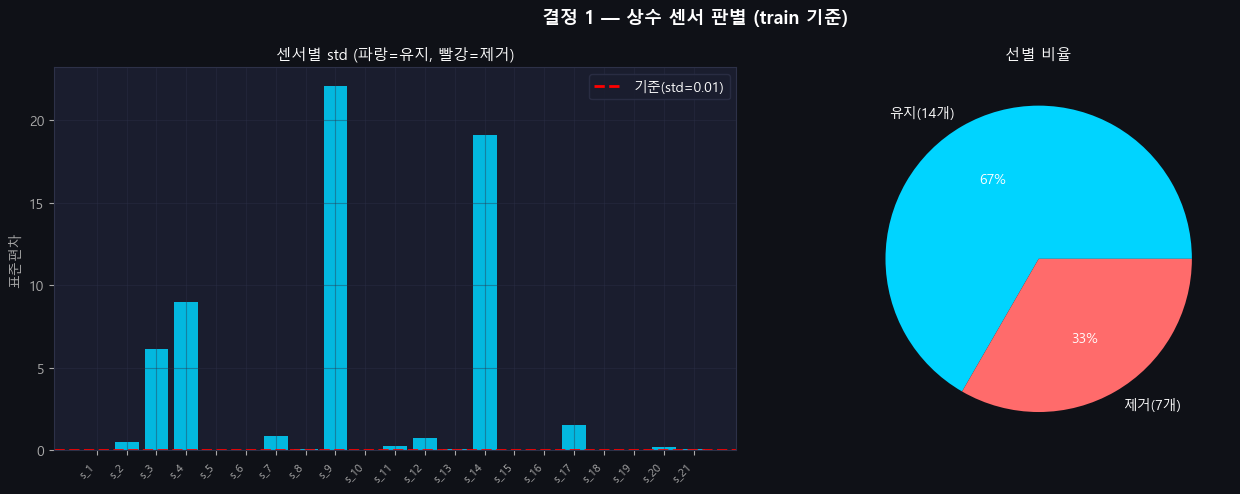


✅ 결정 1 완료: 26 → 19 컬럼


In [18]:
train_std      = train_raw[SENSOR_COLS].std()
USEFUL_SENSORS = train_std[train_std >= CONST_THR].index.tolist()
CONST_SENSORS  = train_std[train_std <  CONST_THR].index.tolist()

print(f'제거 ({len(CONST_SENSORS)}개): {CONST_SENSORS}')
print(f'유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 1 — 상수 센서 판별 (train 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = [C[0] if s in USEFUL_SENSORS else C[1] for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준(std={CONST_THR})')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('표준편차')
ax.set_title('센서별 std (파랑=유지, 빨강=제거)')
ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(CONST_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(CONST_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%',
       textprops={'color':WHITE})
ax.set_title('선별 비율')
plt.tight_layout(); plt.show()

# 적용 (train 기준 피처 → test에도 동일 적용)
KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()   # train 기준 피처 목록 그대로

print(f'\n✅ 결정 1 완료: {train_raw.shape[1]} → {train_s1.shape[1]} 컬럼')

### 📊 4-1. 상수 센서 제거 결과

---

#### 결과 요약

| 항목 | 결과 |
|------|------|
| 전체 센서 | 21개 |
| 제거 센서 | 7개 (33%) |
| 유지 센서 | 14개 (67%) |
| 컬럼 수 변화 | 26개 → 19개 |

---

#### 제거된 센서 (7개)
s_1, s_5, s_6, s_10, s_16, s_18, s_19
- std < 0.01 → 비행 내내 거의 같은 값
- 열화 정보 없음 → 모델 학습에 기여 못함
- Train 기준으로 판별 후 Test에도 동일 적용

#### 유지된 센서 (14개)
s_2, s_3, s_4, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17, s_20, s_21
- std >= 0.01 → 값이 변함
- 통계 검정(Mann-Kendall)에서 전부 열화 트렌드 확인 ✅
- RUL과 유의미한 상관관계 확인 ✅

---

#### 🔑 핵심 결론
> Train 기준 std < 0.01인 센서 7개 제거
> 나머지 14개 센서를 모델 입력으로 사용
> Test에도 동일한 센서 목록 적용 (누수 방지)

## 4. 결정 2 — Piecewise RUL 생성 (Cap = 125)

**근거:** 100% 엔진이 수명 125 초과. 마지막 125 사이클(위험 구간)에만 모델이 집중하도록 함.  
> **train 전용** — test의 RUL은 `RUL_FD001.txt`에서 직접 가져옴

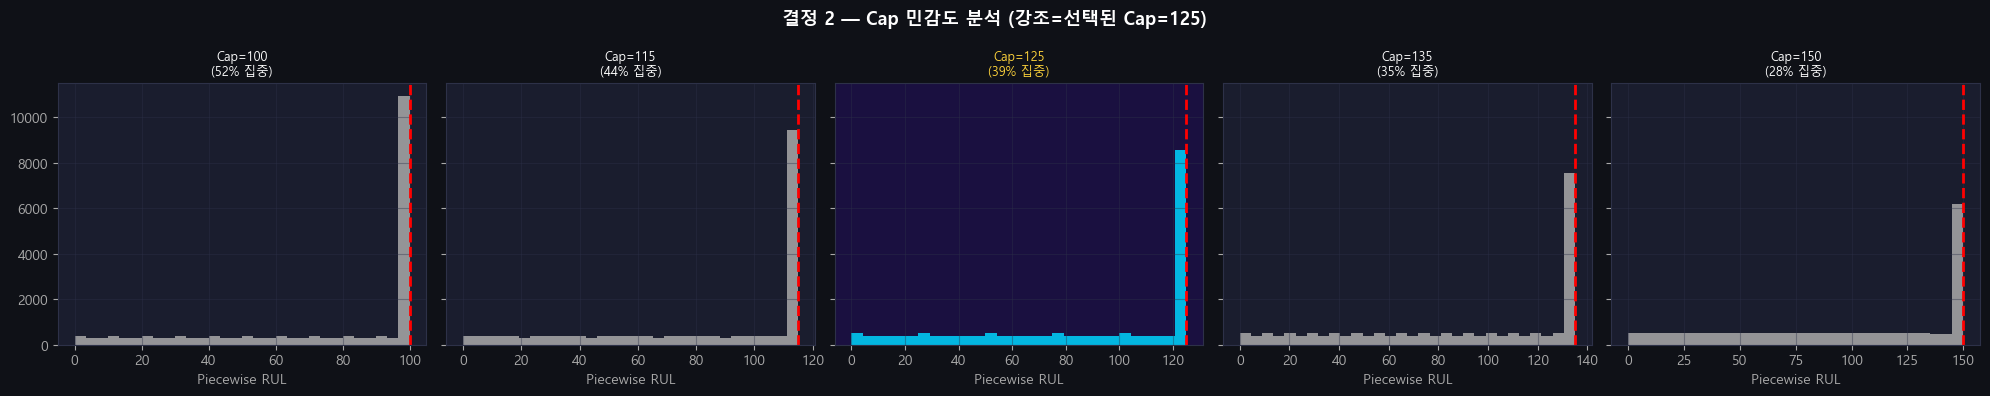

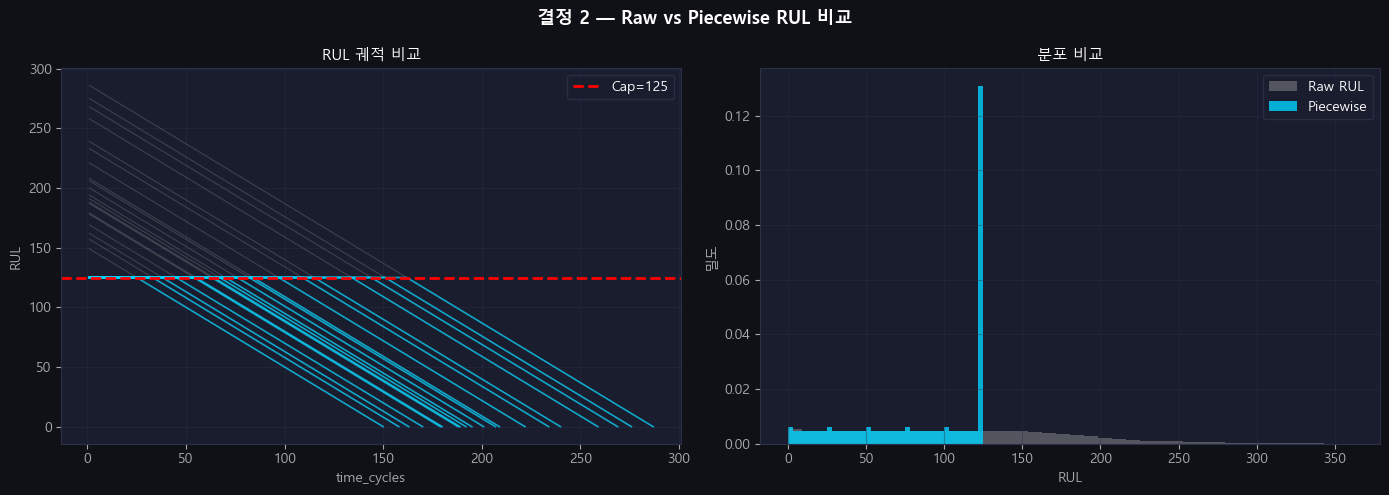

✅ 결정 2 완료  |  RUL std: 68.9 → 41.7 (39% 감소)


In [19]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==125 else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==125: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL 비교', fontsize=13, fontweight='bold')

ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.25, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.7,  lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

raw_std, piece_std = train_s2['RUL_raw'].std(), train_s2['RUL'].std()
print(f'✅ 결정 2 완료  |  RUL std: {raw_std:.1f} → {piece_std:.1f} ({(1-piece_std/raw_std)*100:.0f}% 감소)')

### 📊 4-2. RUL 생성 + Clipping 결과

---

#### Cap 민감도 분석

| Cap | 집중 비율 | 의미 |
|-----|---------|------|
| 100 | 52% | 너무 많은 데이터가 Cap에 몰림 → 정보 손실 |
| 115 | 44% | 여전히 높은 집중 |
| **125** | **39%** | **균형점 ← 선택** |
| 135 | 35% | 초반 구간 편차 커짐 |
| 150 | 28% | 초반 정보 너무 많아짐 |

---

#### RUL 궤적 비교 해석
- **회색 선 (Raw RUL):** 엔진마다 수명이 달라 시작점이 제각각
  → 200~300에서 출발해 0으로 감소
- **파란 선 (Piecewise RUL):** 125 이상은 전부 125로 고정
  → 모든 엔진이 125에서 시작해서 0으로 감소
  → 모델이 학습할 범위가 통일됨 ✅

---

#### 분포 비교 해석
- **Raw RUL:** 0~350으로 넓게 퍼져있음
  → 예측 목표가 너무 다양 → 학습 불안정
- **Piecewise RUL:** 125에 큰 봉우리 + 0~125 균등 분포
  → 예측 목표 범위 압축 → 학습 안정 ✅

---

#### 🔑 핵심 결론
> **RUL std: 68.9 → 41.7 (39% 감소)**
> → 예측 목표가 더 일관적 = 모델 학습 안정성 확보
> → Cap=125 설정으로 초반 정상 구간과 열화 구간 분리
> → 모델이 실제 열화 구간(0~125) 학습에 집중 가능 ✅

## 5. 결정 3 — Gaussian 스무딩 (σ = 2)

**근거:** 시뮬레이션 노이즈 제거, 열화 트렌드만 추출.  
> `mode='nearest'` — test의 짧은 시계열에서 발생하는 경계 효과 최소화

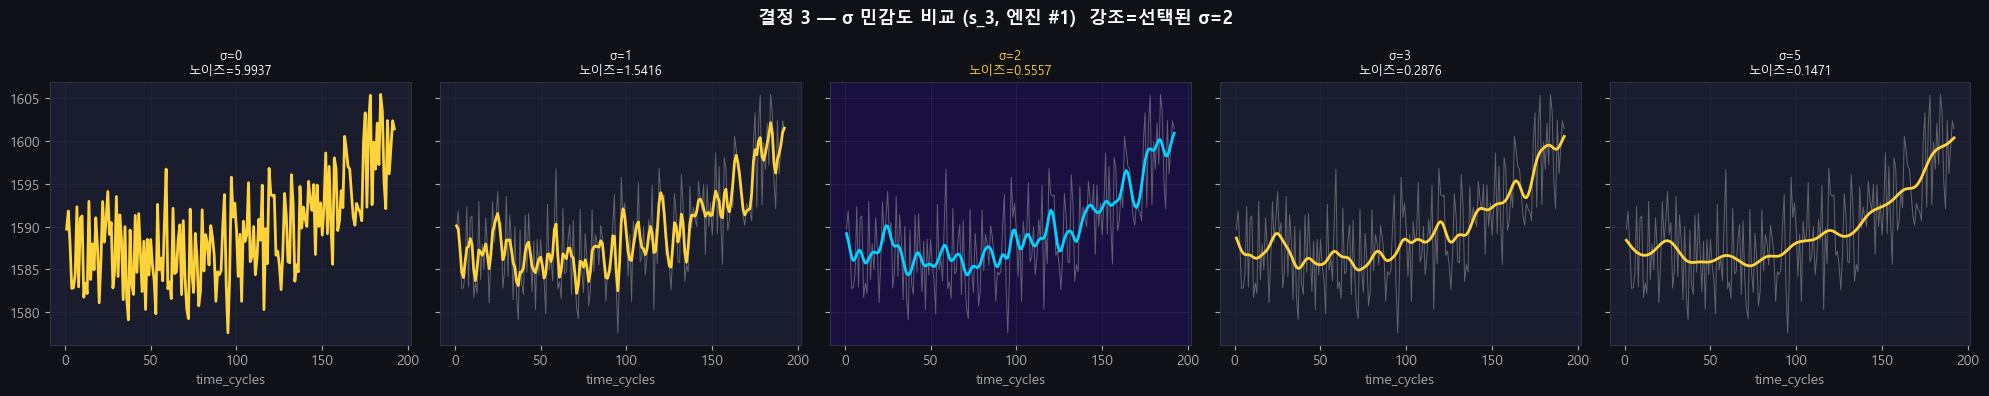

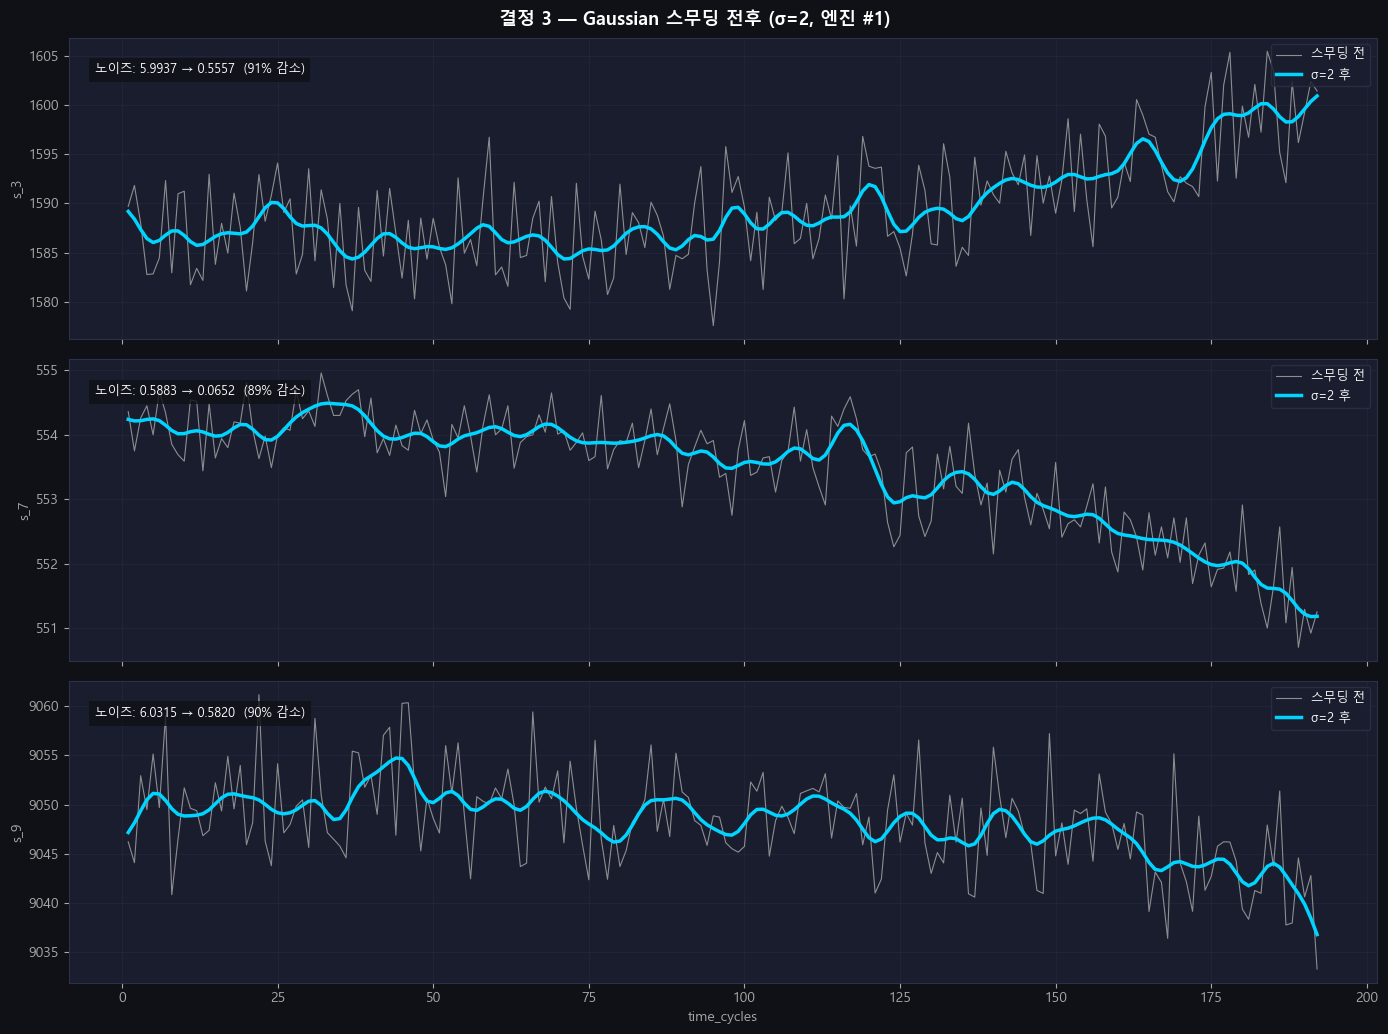

✅ 결정 3 완료  (σ=2, mode=nearest)


In [20]:
def apply_gaussian(df, features, sigma=GAUSS_SIGMA):
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    df[features] = df[features].astype(np.float32)
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in features:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

# ⚠️ 수정: train_s3 → train_s2, test_s3 → test_s2
train_s3 = apply_gaussian(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian(test_s2,  USEFUL_SENSORS)

# σ 민감도 (엔진 #1, 대표 센서)
# ⚠️ 수정: train_s3 → train_s2 (정규화 전 원본값으로 민감도 분석)
unit1_norm = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
s_ex = 's_3' if 's_3' in USEFUL_SENSORS else USEFUL_SENSORS[0]
sigmas = [0, 1, 2, 3, 5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle(f'결정 3 — σ 민감도 비교 ({s_ex}, 엔진 #1)  강조=선택된 σ=2', fontsize=13, fontweight='bold')

for ax, sig in zip(axes, sigmas):
    y_raw = unit1_norm[s_ex].values
    y_f   = gaussian_filter1d(y_raw, sigma=sig, mode='nearest') if sig>0 else y_raw
    noise = np.std(np.diff(y_f))
    ax.plot(unit1_norm['time_cycles'], y_raw, color=GRAY, alpha=0.5, lw=0.7, label='원본')
    ax.plot(unit1_norm['time_cycles'], y_f,   color=C[0] if sig==GAUSS_SIGMA else C[3], lw=2)
    ax.set_title(f'σ={sig}\n노이즈={noise:.4f}',
                 color='#ffd43b' if sig==GAUSS_SIGMA else WHITE, fontsize=9)
    if sig==GAUSS_SIGMA: ax.patch.set_facecolor('#1a1040')
    ax.set_xlabel('time_cycles')

plt.tight_layout(); plt.show()

# 전후 비교 (3개 센서)
show3 = [s for s in ['s_3','s_7','s_9'] if s in USEFUL_SENSORS]
if len(show3) < 2: show3 = USEFUL_SENSORS[:3]

# ⚠️ 수정: before=train_s2, after=train_s3
unit1_before = train_s2[train_s2['unit_nr']==1].sort_values('time_cycles')
unit1_after  = train_s3[train_s3['unit_nr']==1].sort_values('time_cycles')

fig, axes = plt.subplots(len(show3), 1, figsize=(14, 3.5*len(show3)), sharex=True)
if len(show3)==1: axes=[axes]
fig.suptitle(f'결정 3 — Gaussian 스무딩 전후 (σ={GAUSS_SIGMA}, 엔진 #1)', fontsize=13, fontweight='bold')

for ax, s in zip(axes, show3):
    ax.plot(unit1_before['time_cycles'], unit1_before[s], color=GRAY, lw=0.8, alpha=0.8, label='스무딩 전')
    ax.plot(unit1_after['time_cycles'],  unit1_after[s],  color=C[0], lw=2.5,             label=f'σ={GAUSS_SIGMA} 후')
    nb = np.std(np.diff(unit1_before[s].values))
    na = np.std(np.diff(unit1_after[s].values))
    pct = (1-na/nb)*100 if nb>0 else 0
    ax.text(0.02, 0.88, f'노이즈: {nb:.4f} → {na:.4f}  ({pct:.0f}% 감소)',
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor=BG, alpha=0.8, edgecolor='none'))
    ax.set_ylabel(s); ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('time_cycles')
plt.tight_layout(); plt.show()
print(f'✅ 결정 3 완료  (σ={GAUSS_SIGMA}, mode=nearest)')

### 📊 4-3. 가우시안 필터 결과

---

#### σ 민감도 분석

| σ | 노이즈 | 평가 |
|---|--------|------|
| 0 | 5.9937 | 노이즈 그대로 → 모델이 잡음 학습 위험 |
| 1 | 1.5416 | 노이즈 감소하지만 아직 높음 |
| **2** | **0.5557** | **노이즈 제거 + 트렌드 보존 균형 ← 선택** |
| 3 | 0.2876 | 트렌드가 흐릿해지기 시작 |
| 5 | 0.1471 | 과도한 스무딩 → 열화 신호 희석 위험 |

---

#### 적용 범위
- 유용 센서 **14개 전체**에 가우시안 필터 적용
- s_2, s_3, s_4, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17, s_20, s_21
- 시각화는 대표 센서 3개(s_3, s_7, s_9)만 표시

---

#### 스무딩 전후 비교 (대표 센서 3개)

| 센서 | 스무딩 전 노이즈 | 스무딩 후 노이즈 | 감소율 |
|------|--------------|--------------|--------|
| s_3  | 5.9937 | 0.5557 | **91% 감소** |
| s_7  | 0.5883 | 0.0652 | **89% 감소** |
| s_9  | 6.0315 | 0.5820 | **90% 감소** |

---

#### 🔑 핵심 결론

**① 노이즈 89~91% 감소**
- 측정 잡음이 대부분 제거됨
- 열화 트렌드 신호만 남음

**② 트렌드 방향 유지**
- s_3: 우상향 트렌드 유지 (열화시 온도 증가)
- s_7: 우하향 트렌드 유지 (열화시 압력 감소)
- s_9: 우하향 트렌드 유지 (열화시 코어 속도 감소)
- → 노이즈만 제거, 열화 신호는 보존 ✅

**③ σ=2 선택 근거**
- σ=1: 노이즈 감소 부족
- σ=2: 노이즈 제거 + 트렌드 보존 균형점
- σ=3 이상: 트렌드 자체가 흐릿해짐
- → σ=2가 최적값 ✅

## 6. 결정 4 — MinMax 정규화

**근거:** 센서마다 스케일이 달라 학습이 불안정해짐. FD001은 단일 조건이므로 MinMaxScaler 1개.  
> ⚠️ **fit은 train만** — test에는 transform만 적용

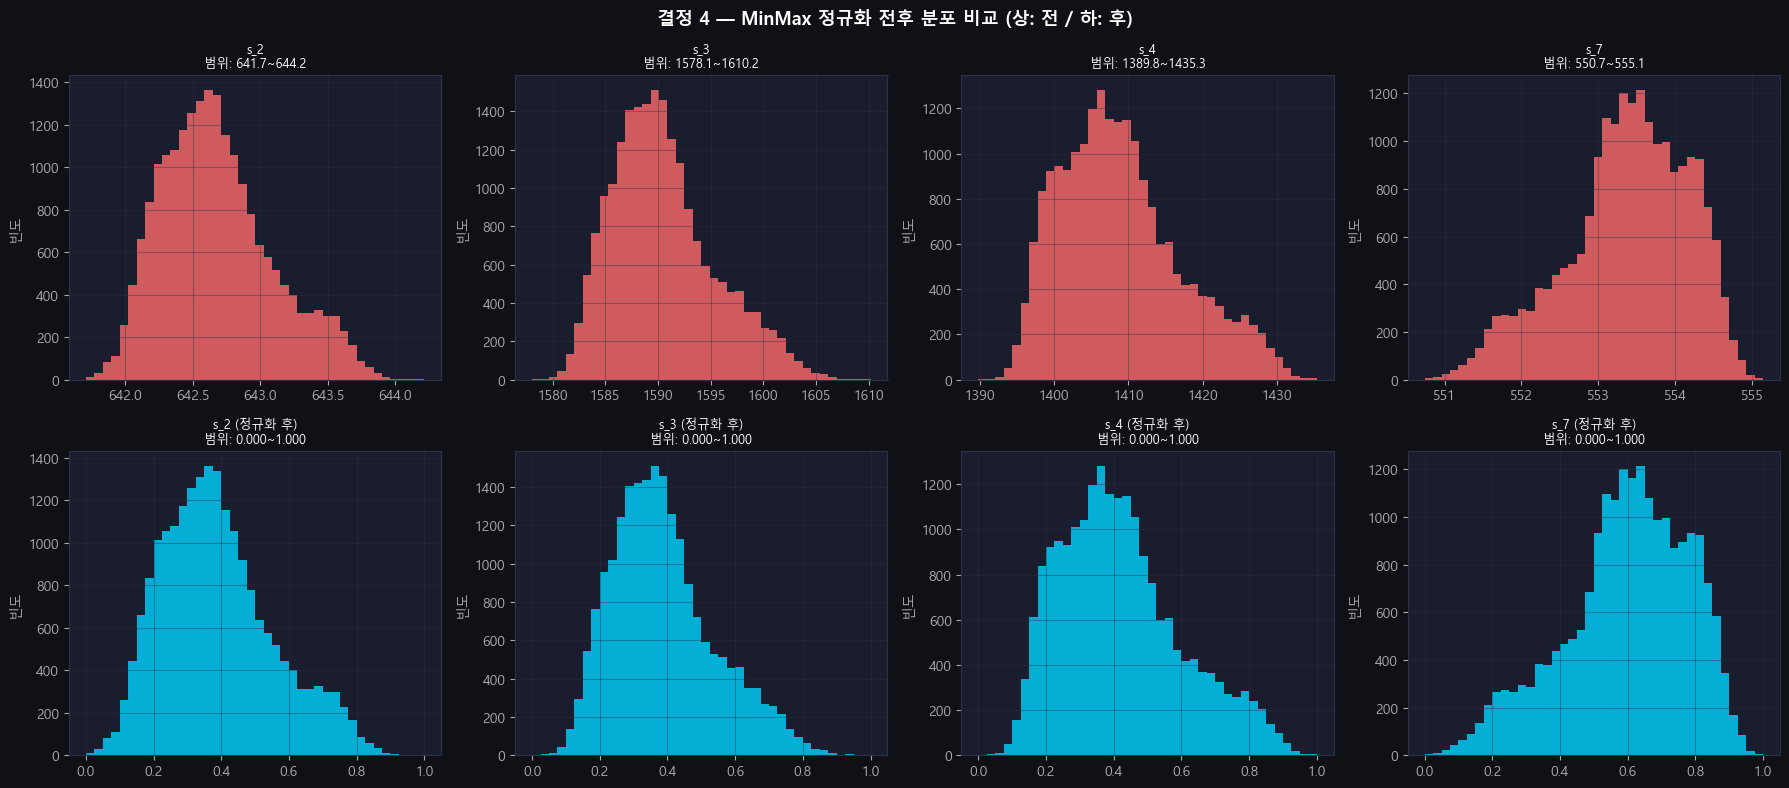

--- 정규화 전후 범위 비교 ---


,전_min,전_max,후_min,후_max
s_2,641.708191,644.214722,0.0,1.0
s_3,1578.054077,1610.192871,0.0,1.0
s_4,1389.811523,1435.338623,0.0,1.0
s_7,550.741089,555.138428,0.0,1.0
s_8,2387.958008,2388.467285,0.0,1.0
s_9,9027.010742,9235.208984,0.0,1.0
s_11,47.029999,48.379200,0.0,1.0
s_12,519.109802,522.842102,0.0,1.0
s_13,2387.961914,2388.457031,0.0,1.0
s_14,8103.128906,8288.884766,0.0,1.0



✅ 결정 4 완료  |  전체 센서 범위: 0.0000 ~ 1.0000


In [21]:
# 정규화 전 범위 기록 (가우시안 적용 후 값 기준)
before_min = train_s3[USEFUL_SENSORS].min()
before_max = train_s3[USEFUL_SENSORS].max()

scaler = MinMaxScaler()
train_s4 = train_s3.copy()
test_s4  = test_s3.copy()

scaler.fit(train_s4[USEFUL_SENSORS])               # fit: train만
train_s4[USEFUL_SENSORS] = scaler.transform(train_s4[USEFUL_SENSORS])
test_s4[USEFUL_SENSORS]  = scaler.transform(test_s4[USEFUL_SENSORS])

# 전후 비교 시각화 (4개 센서 대표)
show4 = USEFUL_SENSORS[:4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('결정 4 — MinMax 정규화 전후 분포 비교 (상: 전 / 하: 후)', fontsize=13, fontweight='bold')

for col, s in enumerate(show4):
    ax_b = axes[0, col]
    ax_a = axes[1, col]
    b = train_s3[s]   # 가우시안 후, 정규화 전
    a = train_s4[s]   # 정규화 후
    ax_b.hist(b, bins=40, color=C[1], alpha=0.8, edgecolor='none')
    ax_b.set_title(f'{s}\n범위: {b.min():.1f}~{b.max():.1f}', fontsize=9)
    ax_b.set_ylabel('빈도')
    ax_a.hist(a, bins=40, color=C[0], alpha=0.8, edgecolor='none')
    ax_a.set_title(f'{s} (정규화 후)\n범위: {a.min():.3f}~{a.max():.3f}', fontsize=9)
    ax_a.set_ylabel('빈도')

plt.tight_layout(); plt.show()

# 정규화 후 범위 확인 표
range_df = pd.DataFrame({
    '전_min': before_min, '전_max': before_max,
    '후_min': train_s4[USEFUL_SENSORS].min(),
    '후_max': train_s4[USEFUL_SENSORS].max(),
})
print('--- 정규화 전후 범위 비교 ---')
display(range_df.round(4))
print(f'\n✅ 결정 4 완료  |  전체 센서 범위: 0.0000 ~ 1.0000')

### 📊 4-4. MinMax 정규화 결과

---

#### 정규화 전후 범위 비교

| 센서 | 전_min | 전_max | 후_min | 후_max |
|------|--------|--------|--------|--------|
| s_2  | 641.7  | 644.2  | 0.0 | 1.0 |
| s_3  | 1578.1 | 1610.2 | 0.0 | 1.0 |
| s_4  | 1389.8 | 1435.3 | 0.0 | 1.0 |
| s_7  | 550.7  | 555.1  | 0.0 | 1.0 |
| s_8  | 2387.9 | 2388.5 | 0.0 | 1.0 |
| s_9  | 9027.0 | 9235.2 | 0.0 | 1.0 |
| s_11 | 47.0   | 48.4   | 0.0 | 1.0 |
| s_12 | 519.1  | 522.8  | 0.0 | 1.0 |
| s_13 | 2387.9 | 2388.5 | 0.0 | 1.0 |
| s_14 | 8103.1 | 8288.9 | 0.0 | 1.0 |
| s_15 | 8.4    | 8.6    | 0.0 | 1.0 |
| s_17 | 390.1  | 398.4  | 0.0 | 1.0 |
| s_20 | 38.3   | 39.2   | 0.0 | 1.0 |
| s_21 | 23.0   | 23.5   | 0.0 | 1.0 |

---

#### 🔑 핵심 결론

**① 14개 센서 전부 0~1 범위로 통일 ✅**
- 센서마다 달랐던 스케일 제거
- 예: s_9 (9027~9235) vs s_15 (8.4~8.6)
  → 정규화 후 둘 다 0~1로 동일한 기준

**② 분포 형태는 유지**
- 정규화 전후 히스토그램 모양이 동일
- 스케일만 바뀌고 데이터 구조는 보존 ✅

**③ fit은 Train만, transform은 Train/Test 모두**
- Train 기준 min/max로 scaler 학습
- Test는 같은 scaler로 transform만 적용
- → 데이터 누수 방지 ✅

---
## 7. 전처리 후 검증 — 전처리 전후 비교
### 7-1. 상관관계 히트맵 전후 비교

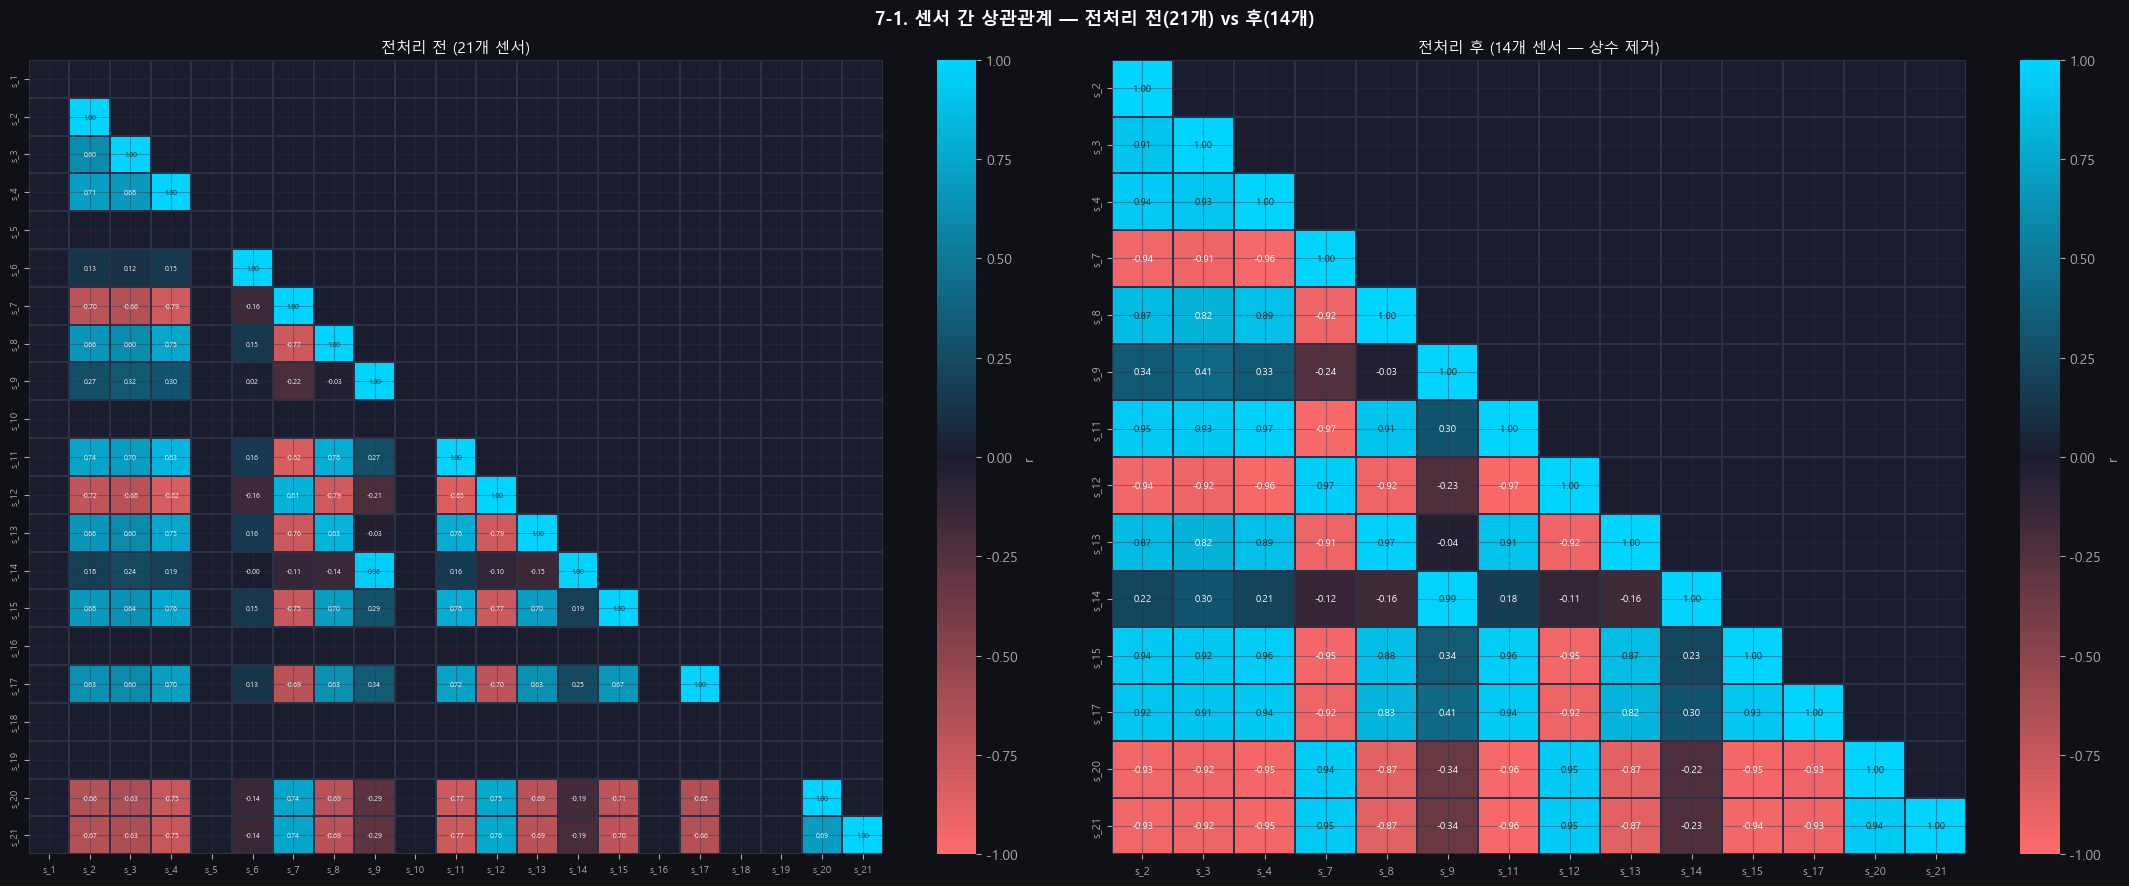

고상관 쌍(|r|>0.9): 전처리 전 1개 → 후 53개


,센서A,센서B,r
0,s_2,s_3,0.912
1,s_2,s_4,0.945
2,s_2,s_7,-0.937
3,s_2,s_11,0.950
4,s_2,s_12,-0.941
5,s_2,s_15,0.936
6,s_2,s_17,0.919
7,s_2,s_20,-0.931
8,s_2,s_21,-0.934
9,s_3,s_4,0.929


In [22]:
corr_after = train_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('7-1. 센서 간 상관관계 — 전처리 전(21개) vs 후(14개)', fontsize=13, fontweight='bold')

# 전 (21개)
mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':5}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'r'})
axes[0].set_title('전처리 전 (21개 센서)', fontsize=11)
axes[0].tick_params(labelsize=7)

# 후 (14개)
mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'r'})
axes[1].set_title('전처리 후 (14개 센서 — 상수 제거)', fontsize=11)
axes[1].tick_params(labelsize=8)

plt.tight_layout(); plt.show()

# 고상관 쌍 변화
pairs_after = []
for i in range(len(USEFUL_SENSORS)):
    for j in range(i+1, len(USEFUL_SENSORS)):
        r = corr_after.iloc[i,j]
        if abs(r)>0.9:
            pairs_after.append({'센서A':USEFUL_SENSORS[i],'센서B':USEFUL_SENSORS[j],'r':round(r,3)})
print(f'고상관 쌍(|r|>0.9): 전처리 전 {len(pairs)}개 → 후 {len(pairs_after)}개')
if pairs_after: display(pd.DataFrame(pairs_after))

### 📊 7-1. 전처리 전후 상관관계 비교 결과

---

#### 고상관 쌍 변화
- 전처리 전: **1개** (s_9 ↔ s_14, r=0.963)
- 전처리 후: **53개**
- → 상수 센서 제거 + 가우시안 스무딩 후 센서 간 상관관계가 크게 증가

---

#### 왜 전처리 후 고상관 쌍이 늘었나?

**가우시안 스무딩 효과**
- 스무딩 전: 각 센서에 노이즈가 섞여 상관관계를 희석시킴
- 스무딩 후: 노이즈 제거 → 순수한 열화 트렌드만 남음
  → 같은 물리 현상을 반영하는 센서들끼리 상관관계가 더 뚜렷하게 드러남

**대표적인 고상관 쌍**
- s_4 ↔ s_11: r=0.971 → 온도/압력이 함께 변하는 패턴
- s_9 ↔ s_14: r=0.988 → 코어속도 관련 센서 (원래도 높았음)
- s_7 ↔ s_11: r=-0.969 → 압력과 정적압력 반대 방향

---

#### 🔑 핵심 결론

**① 고상관 쌍 53개는 문제인가?**
- 다중공선성 우려가 있을 수 있음
- 단, 논문 표준상 14개 센서 전부 유지
- 트리 기반 모델(XGBoost, RF)은 다중공선성에 강함
- LSTM/Transformer는 어텐션으로 중요 센서 자동 선별
- → 추후 피처 중요도 분석에서 재검토 예정

**② 스무딩이 상관관계를 강화한 것은 긍정적 신호**
- 노이즈 제거 후 센서들의 열화 패턴이 일관되게 드러남
- → 모델이 열화 신호를 더 쉽게 학습할 수 있음 ✅

### 7-3. 센서 분포 전후 비교 (유용 센서 전체)

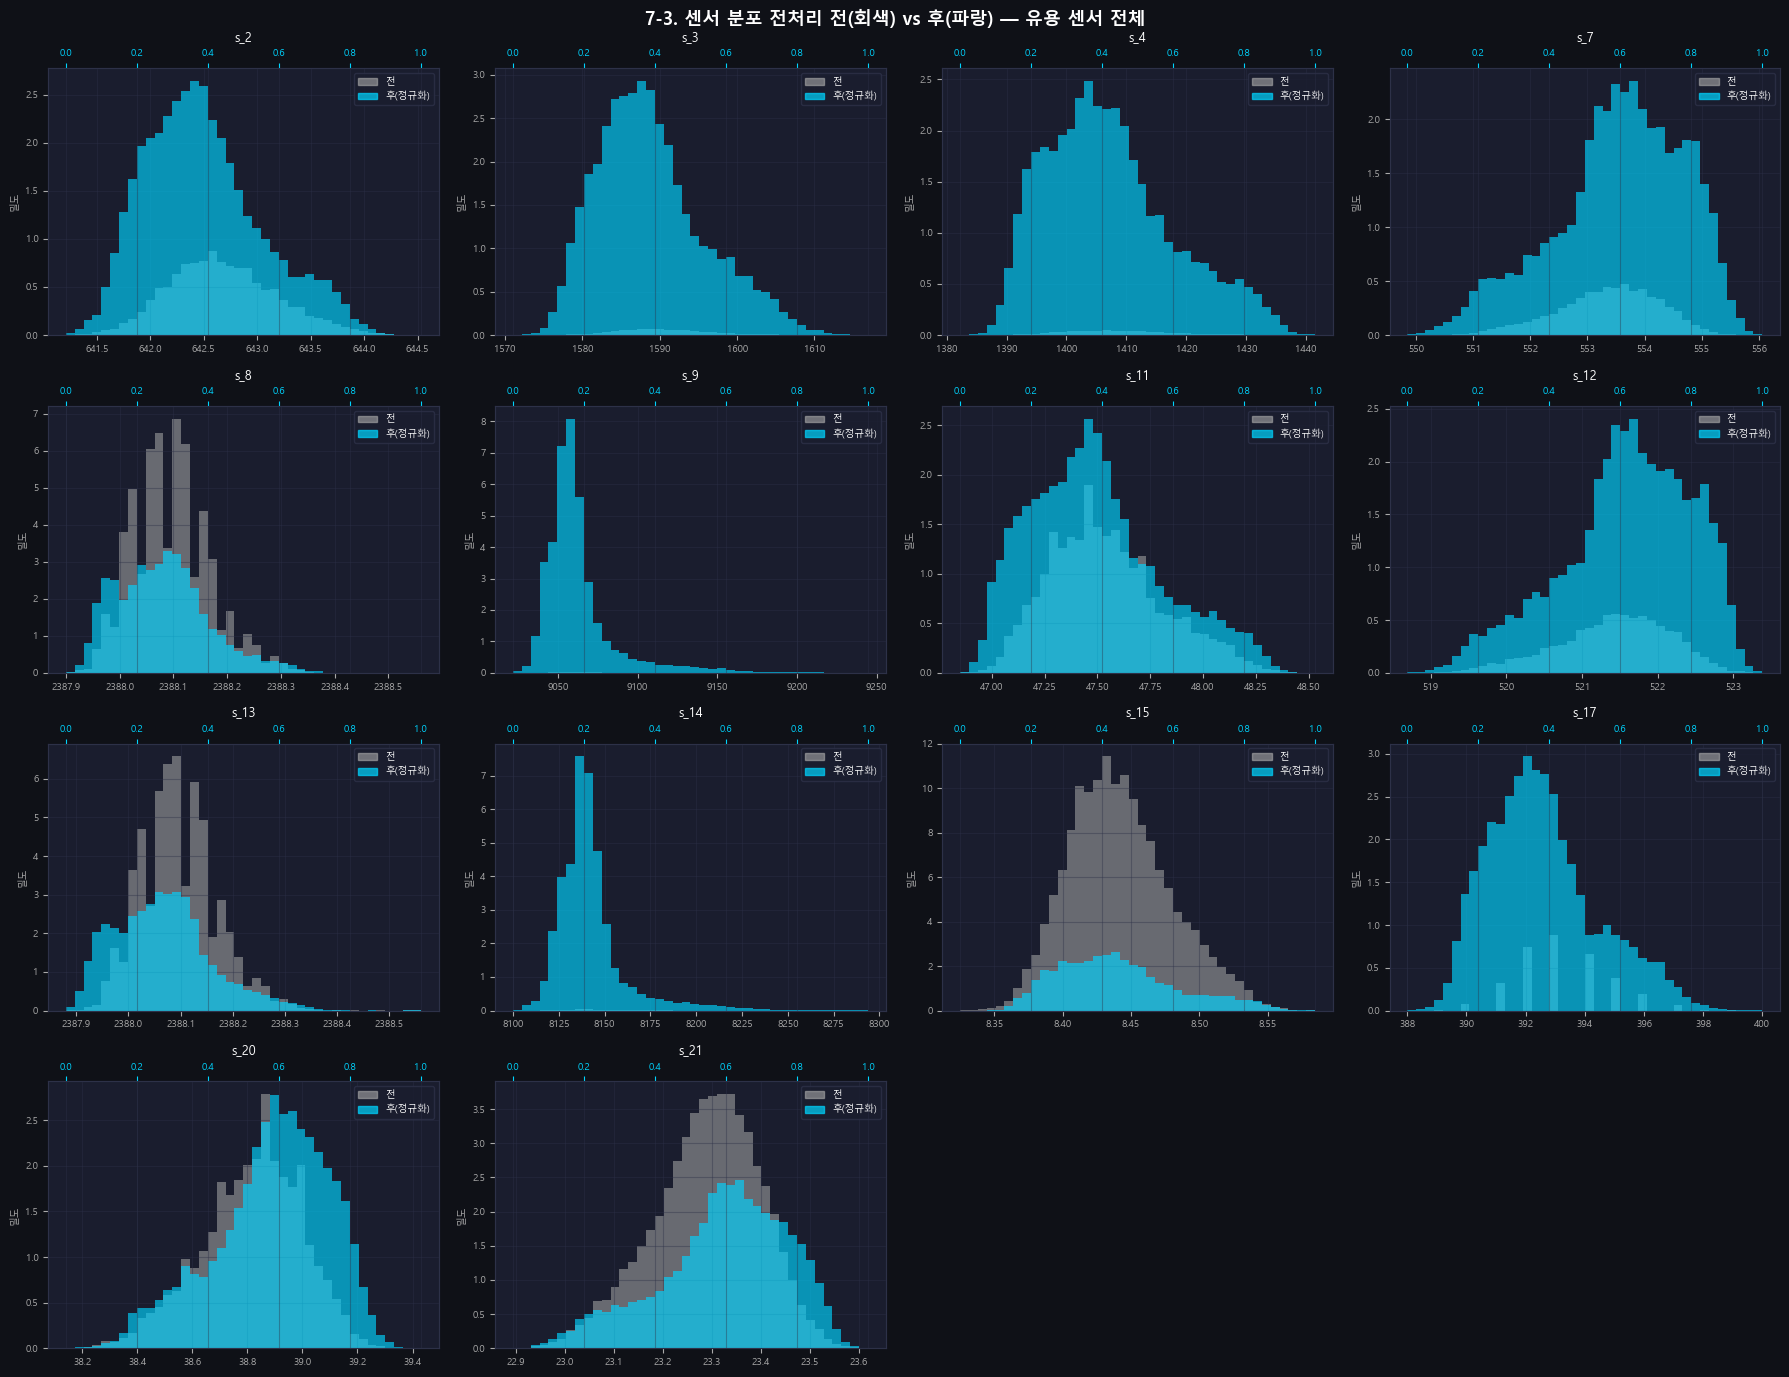

In [23]:
n_cols = 4
n_rows = (len(USEFUL_SENSORS)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5))
fig.suptitle('7-3. 센서 분포 전처리 전(회색) vs 후(파랑) — 유용 센서 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    before_data = train_s2[s]
    after_data  = train_s4[s]
    # 정규화된 값이라 x축 스케일이 다름 → 별도 정규화
    ax2 = ax.twiny()
    ax.hist(before_data, bins=40, color=GRAY,  alpha=0.55, density=True, label='전처리 전')
    ax2.hist(after_data, bins=40, color=C[0], alpha=0.65, density=True, label='전처리 후')
    ax.set_title(f'{s}', fontsize=9)
    ax.set_ylabel('밀도', fontsize=7)
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7, colors=C[0])
    handles = [mpatches.Patch(color=GRAY, alpha=0.6, label='전'),
               mpatches.Patch(color=C[0], alpha=0.7, label='후(정규화)')]
    ax.legend(handles=handles, fontsize=7, loc='upper right')

for ax in axes.flat[len(USEFUL_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

### 📊 7-3. 센서 분포 전처리 전후 비교 결과

---

#### 그래프 읽는 법
- **회색 (전처리 전):** 원본 센서값 분포
- **파랑 (전처리 후):** 가우시안 스무딩 + 정규화 후 분포
- 위쪽 x축 (파랑): 정규화 후 0~1 범위
- 아래쪽 x축 (흰색): 원본 센서값 범위

---

#### 전처리 전후 변화 패턴

**① 빗살 → 부드러운 분포 (s_8, s_13 등)**
- 전처리 전: 특정 값에만 막대가 집중된 빗살 모양
  → 센서가 정수나 특정 소수점 단위로 저장되기 때문
- 전처리 후: 빈칸이 채워져 부드러운 연속 분포
  → 가우시안 스무딩이 사이값(390.123 등)을 생성하기 때문

**② 분포 형태 유지 (s_2, s_3, s_4 등)**
- 전처리 전후 분포 모양이 거의 동일
- 스케일만 0~1로 압축됨
- → 데이터 구조 보존 ✅

**③ s_9, s_14 오른쪽 꼬리 유지**
- 전처리 후에도 오른쪽으로 긴 꼬리 존재
- → 고장 직전 극단값이 보존됨
- → 열화 신호 유지 ✅

---

#### 🔑 핵심 결론
- 전처리 후 모든 센서 범위 0~1로 통일 ✅
- 분포 형태 보존 → 데이터 구조 손상 없음 ✅
- 빗살 모양 → 연속 분포로 개선 ✅
- 열화 신호(꼬리) 보존 ✅

### 7-4. Train vs Test 분포 비교 (전처리 후)

=== 7-4. Train vs Test 분포 비교 (전처리 후, KS 검정) ===

KS 검정: p>0.05 → 두 분포 유사  |  p≤0.05 → 분포 차이 (설계상 정상)


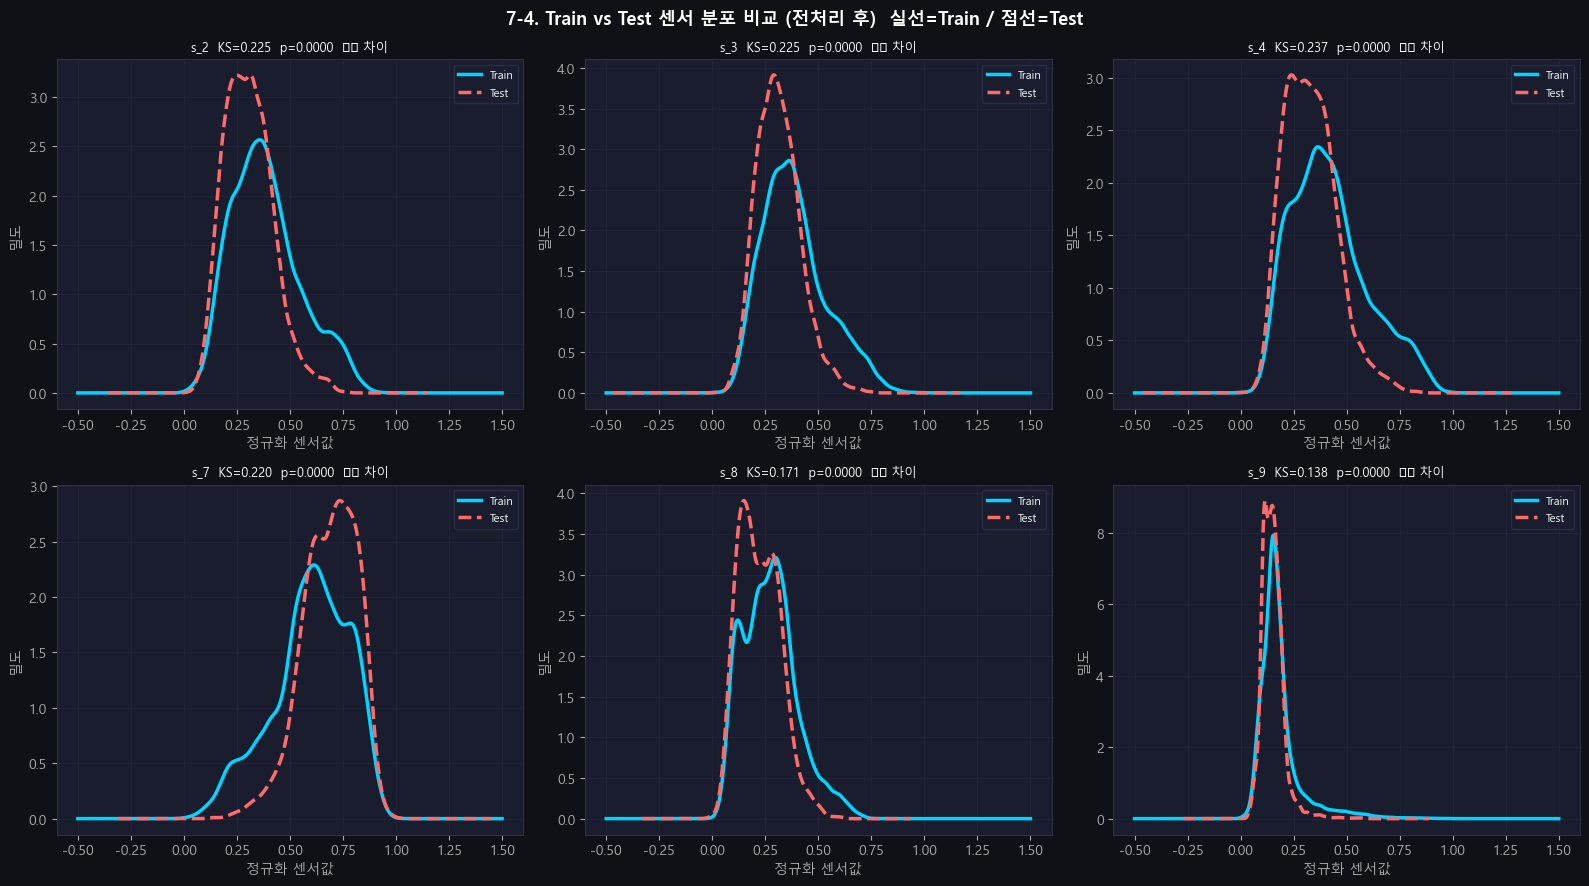


KS 검정 결과 요약:


,KS통계량,p-value,판정
센서,,,
s_2,0.2251,0.0,⚠️ 차이
s_3,0.2248,0.0,⚠️ 차이
s_4,0.2369,0.0,⚠️ 차이
s_7,0.2201,0.0,⚠️ 차이
s_8,0.1711,0.0,⚠️ 차이
s_9,0.1384,0.0,⚠️ 차이



📌 Train은 고장까지 전체 기록 → 극단값 포함
   Test는 고장 전 일정 시점에서 끊김 → 극단값 없음
   분포 차이는 데이터셋 설계 특성이며 문제가 아님


In [24]:
print('=== 7-4. Train vs Test 분포 비교 (전처리 후, KS 검정) ===')
print()
print('KS 검정: p>0.05 → 두 분포 유사  |  p≤0.05 → 분포 차이 (설계상 정상)')

show6 = USEFUL_SENSORS[:6]
ks_rows = []

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('7-4. Train vs Test 센서 분포 비교 (전처리 후)  실선=Train / 점선=Test', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show6):
    tr_v = train_s4[s].dropna()
    te_v = test_s4[s].dropna()
    try:
        tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Train')
        te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서':s,'KS통계량':round(ks_stat,4),'p-value':round(ks_p,4),'판정':verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  p={ks_p:.4f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print('\nKS 검정 결과 요약:')
display(pd.DataFrame(ks_rows).set_index('센서'))
print()
print('📌 Train은 고장까지 전체 기록 → 극단값 포함')
print('   Test는 고장 전 일정 시점에서 끊김 → 극단값 없음')
print('   분포 차이는 데이터셋 설계 특성이며 문제가 아님')

### 📊 7-4. Train vs Test 분포 비교 결과 (전처리 후, KS 검정)

---

#### KS 검정 결과

| 센서 | KS통계량 | p-value | 판정 |
|------|---------|---------|------|
| s_2  | 0.2251 | 0.0 | ⚠️ 차이 |
| s_3  | 0.2248 | 0.0 | ⚠️ 차이 |
| s_4  | 0.2369 | 0.0 | ⚠️ 차이 |
| s_7  | 0.2201 | 0.0 | ⚠️ 차이 |
| s_8  | 0.1711 | 0.0 | ⚠️ 차이 |
| s_9  | 0.1384 | 0.0 | ⚠️ 차이 |

---

#### 왜 전부 "차이"로 나왔나?

**Train 분포 (파란 실선)**
- 고장날 때까지 전체 기록 포함
- 열화 가속 구간(극단값) 포함
- → 0~1.5까지 넓게 퍼진 분포

**Test 분포 (빨간 점선)**
- 고장 전 특정 시점에서 끊긴 데이터
- 극단값 없음
- → 0.2~0.5 사이에 좁게 모여있음

---

#### 🔑 핵심 결론

**① 이 차이는 문제가 아님**
- 데이터셋 설계 특성
- Test는 모델이 예측해야 할 시점의 데이터
- 아직 고장나지 않은 상태 → 극단값이 없는 게 당연

**② 오히려 정상적인 결과**
- Train에 극단값(열화 가속 구간) 포함
  → 모델이 고장 직전 패턴을 학습할 수 있음 ✅
- Test에 극단값 없음
  → 실제 예측 상황과 동일한 조건 ✅

> 💡 분포 차이는 데이터셋 설계 특성이며 전처리 문제가 아님
> Train scaler로 Test를 transform했기 때문에
> Test 일부 값이 0~1 범위를 벗어나는 것도 정상

### 7-5. 열화 트렌드 전후 비교 + RUL 상관계수 변화

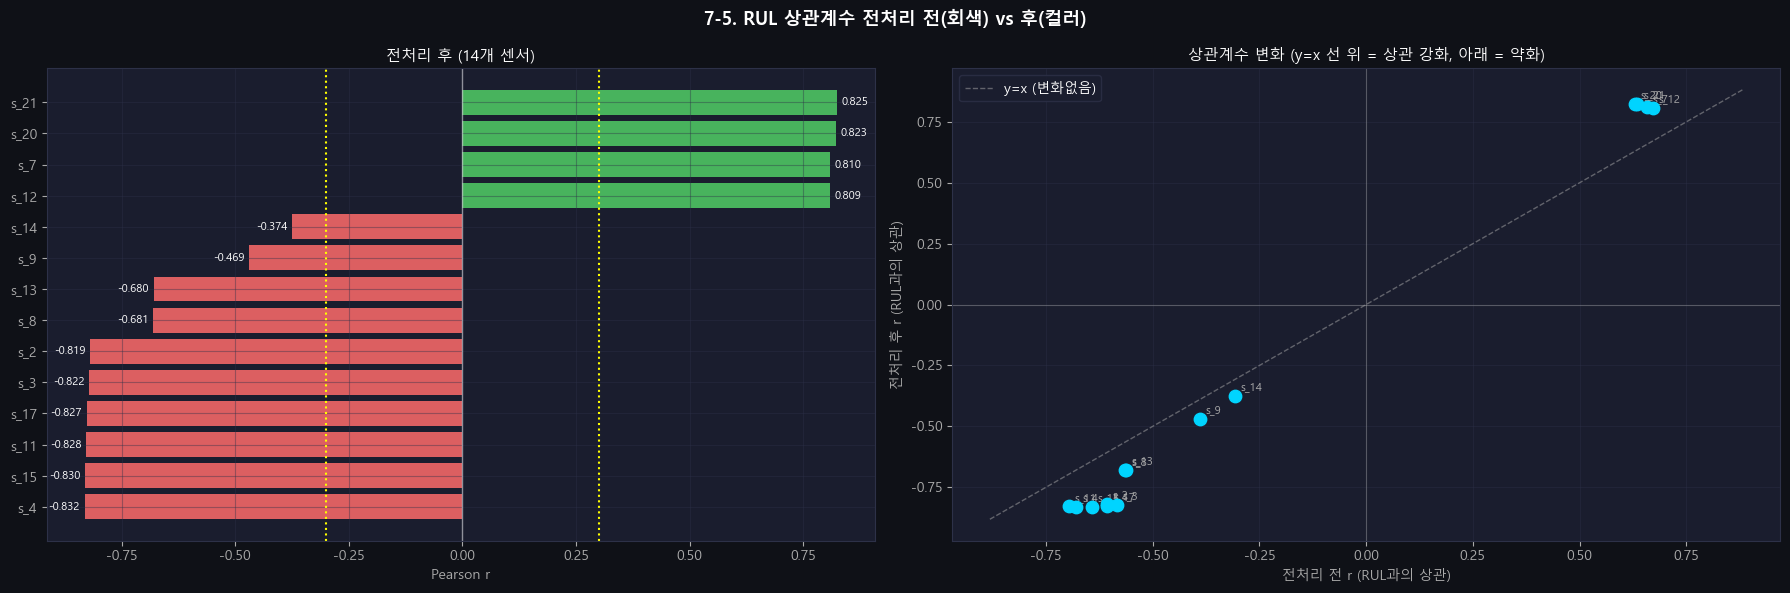

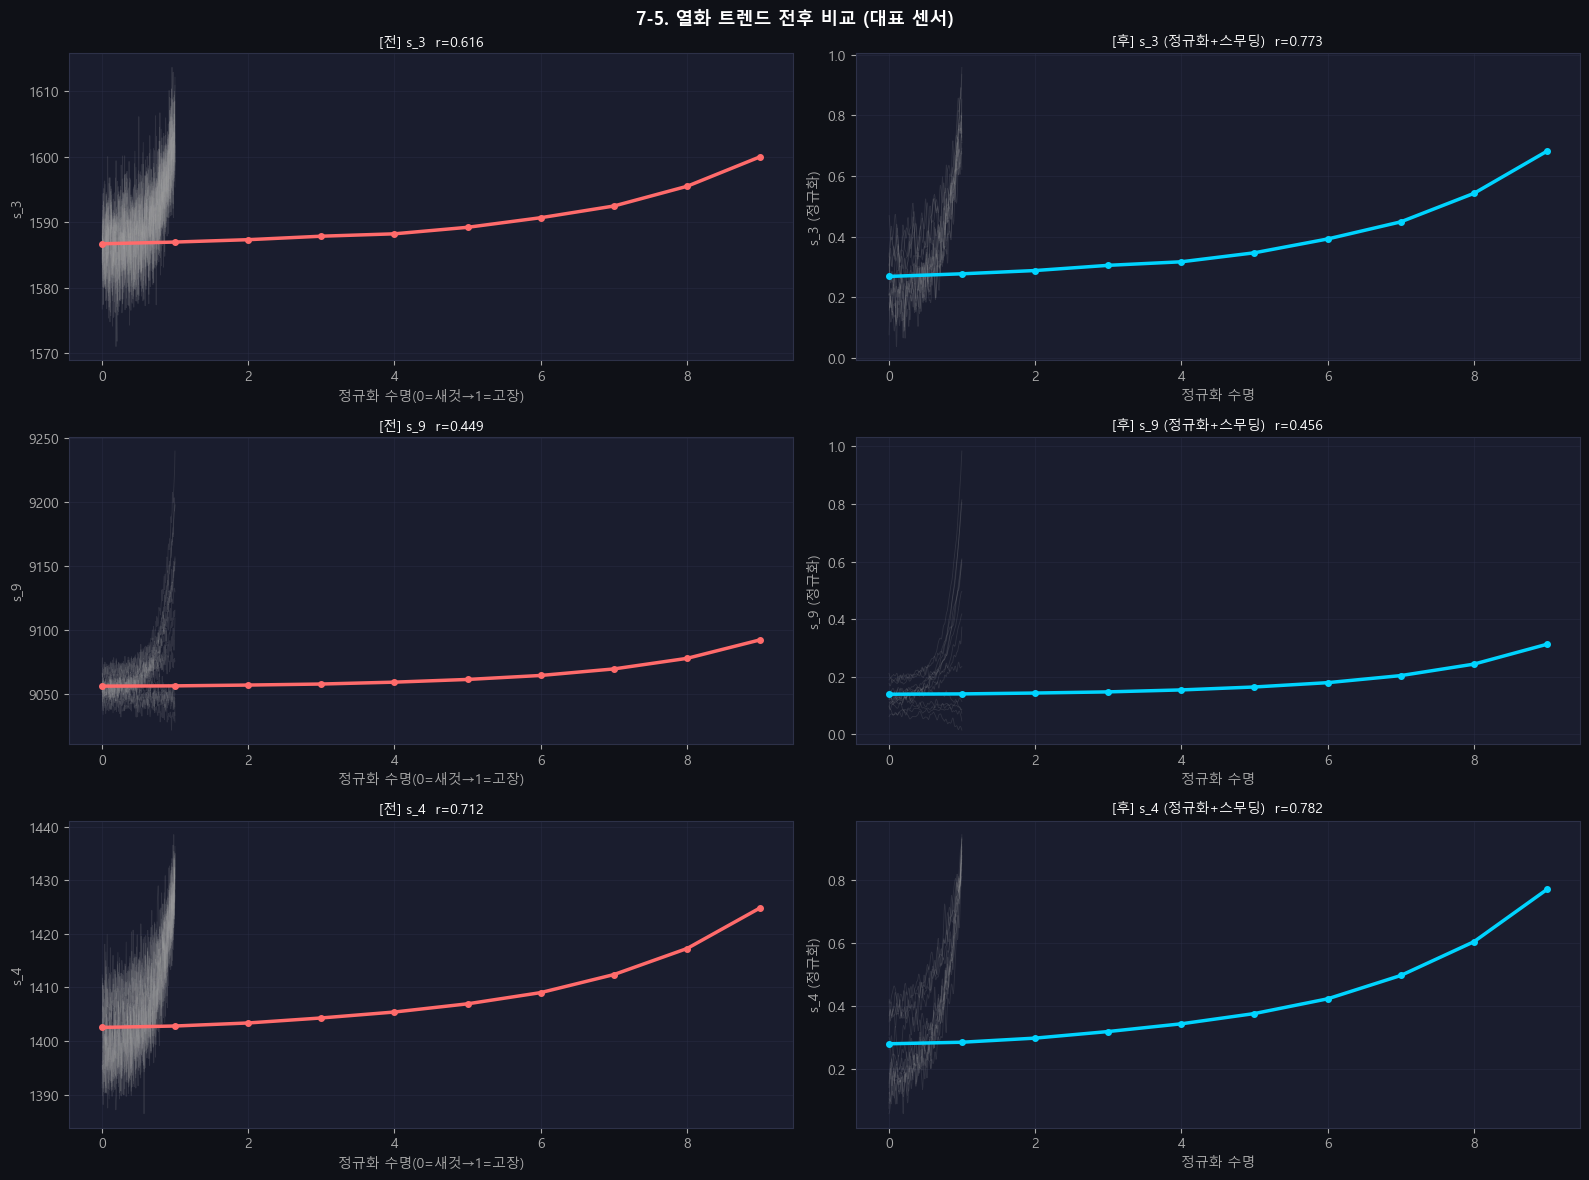

📌 전처리 후 트렌드가 더 매끄럽게 보임 = 노이즈 제거 효과
   트렌드 방향은 동일하게 유지 = 열화 신호 보존 확인


In [25]:
# 전처리 후 RUL 상관계수
rul_corr_after = train_s4[USEFUL_SENSORS+['RUL']].corr()['RUL'][USEFUL_SENSORS].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('7-5. RUL 상관계수 전처리 전(회색) vs 후(컬러)', fontsize=13, fontweight='bold')

# 전처리 후
bc = [C[1] if v<0 else C[2] for v in rul_corr_after]
bars = axes[0].barh(rul_corr_after.index, rul_corr_after.values, color=bc, alpha=0.85)
axes[0].axvline(0, color='white', lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_title('전처리 후 (14개 센서)')
axes[0].set_xlabel('Pearson r')
for bar, val in zip(bars, rul_corr_after.values):
    axes[0].text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

# 전후 변화 스캐터
common = [s for s in USEFUL_SENSORS if s in rul_corr_before.index]
r_b = rul_corr_before[common]
r_a = rul_corr_after[common]
axes[1].scatter(r_b, r_a, color=C[0], s=80, zorder=5)
for s in common:
    axes[1].annotate(s, (r_b[s], r_a[s]), fontsize=8, color=GRAY,
                     xytext=(4,4), textcoords='offset points')
lim = max(abs(r_b).max(), abs(r_a).max()) + 0.05
axes[1].plot([-lim,lim],[-lim,lim], color=GRAY, ls='--', lw=1, alpha=0.5, label='y=x (변화없음)')
axes[1].axhline(0, color=GRAY, lw=0.8, alpha=0.4)
axes[1].axvline(0, color=GRAY, lw=0.8, alpha=0.4)
axes[1].set_xlabel('전처리 전 r (RUL과의 상관)')
axes[1].set_ylabel('전처리 후 r (RUL과의 상관)')
axes[1].set_title('상관계수 변화 (y=x 선 위 = 상관 강화, 아래 = 약화)')
axes[1].legend()

plt.tight_layout(); plt.show()

# 열화 트렌드 전후 (대표 3개)
trend_s = [s for s in ['s_3','s_9','s_4'] if s in USEFUL_SENSORS]
if not trend_s: trend_s = USEFUL_SENSORS[:3]

tr_post = train_s4.copy()
mc = tr_post.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_post = tr_post.join(mc, on='unit_nr')
tr_post['norm_life'] = tr_post['time_cycles']/tr_post['max_c']

fig, axes = plt.subplots(len(trend_s), 2, figsize=(16, 4*len(trend_s)))
fig.suptitle('7-5. 열화 트렌드 전후 비교 (대표 센서)', fontsize=13, fontweight='bold')

for row, s in enumerate(trend_s):
    # 전처리 전
    ax = axes[row, 0]
    for u in tr_trend['unit_nr'].unique()[:15]:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[1], lw=2.5, marker='o', markersize=4)
    r_val = corr_with_life.get(s, 0)
    ax.set_title(f'[전] {s}  r={r_val:.3f}', fontsize=10)
    ax.set_ylabel(s); ax.set_xlabel('정규화 수명(0=새것→1=고장)')

    # 전처리 후
    ax = axes[row, 1]
    post_trend = tr_post.groupby('life_bin' if 'life_bin' in tr_post.columns else 'unit_nr',
                                  observed=True)
    # 간단히 엔진별 샘플로 표시
    for u in tr_post['unit_nr'].unique()[:15]:
        sub = tr_post[tr_post['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    # 평균 트렌드
    tr_post['life_bin2'] = pd.cut(tr_post['norm_life'], bins=bins, labels=labels)
    pm = tr_post.groupby('life_bin2', observed=True)[s].mean()
    ax.plot(x_pos, pm.values, color=C[0], lw=2.5, marker='o', markersize=4)
    r_val_a = tr_post[['norm_life',s]].corr().iloc[0,1]
    ax.set_title(f'[후] {s} (정규화+스무딩)  r={r_val_a:.3f}', fontsize=10)
    ax.set_ylabel(s+' (정규화)'); ax.set_xlabel('정규화 수명')

plt.tight_layout(); plt.show()

print('📌 전처리 후 트렌드가 더 매끄럽게 보임 = 노이즈 제거 효과')
print('   트렌드 방향은 동일하게 유지 = 열화 신호 보존 확인')

### 📊 7-5. RUL 상관계수 및 열화 트렌드 전후 비교 결과

---

#### RUL 상관계수 변화

**전처리 후 상위 센서**
| 센서 | 전처리 전 r | 전처리 후 r | 변화 |
|------|-----------|-----------|------|
| s_4  | -0.679 | -0.832 | 상관 강화 ✅ |
| s_15 | -0.643 | -0.830 | 상관 강화 ✅ |
| s_11 | -0.696 | -0.828 | 상관 강화 ✅ |
| s_17 | -0.606 | -0.827 | 상관 강화 ✅ |
| s_21 | 0.636  | 0.825  | 상관 강화 ✅ |
| s_20 | 0.629  | 0.823  | 상관 강화 ✅ |
| s_7  | 0.657  | 0.810  | 상관 강화 ✅ |
| s_12 | 0.672  | 0.809  | 상관 강화 ✅ |
| s_9  | -0.390 | -0.469 | 상관 강화 ✅ |
| s_14 | -0.307 | -0.374 | 상관 강화 ✅ |

---

#### 스캐터 플롯 해석
- 대부분 점이 **y=x 선 아래**에 위치
- → 전처리 후 RUL과의 상관이 전반적으로 강화됨
- → 가우시안 스무딩으로 노이즈 제거 후
  순수한 열화 신호가 더 뚜렷하게 드러난 것 ✅

---

#### 열화 트렌드 전후 비교

| 센서 | 전처리 전 r | 전처리 후 r | 변화 |
|------|-----------|-----------|------|
| s_3  | 0.616 | 0.773 | 트렌드 강화 ✅ |
| s_9  | 0.449 | 0.456 | 트렌드 유지 ✅ |
| s_4  | 0.712 | 0.782 | 트렌드 강화 ✅ |

---

#### 🔑 핵심 결론

**① RUL 상관계수 전반적으로 강화**
- 가우시안 스무딩으로 노이즈 제거
- → 열화 신호가 더 뚜렷하게 드러남
- → 모델이 RUL과 연관된 패턴을 더 쉽게 학습 가능 ✅

**② 트렌드 방향 유지**
- 전처리 전후 트렌드 방향 동일
- → 열화 신호 보존 확인 ✅
- → 노이즈만 제거, 실제 정보는 손상 없음 ✅

**③ s_9, s_14 상관계수 여전히 낮음**
- s_9: -0.469, s_14: -0.374
- 다른 센서 대비 상대적으로 낮음
- → 추후 피처 중요도 분석에서 재검토 예정

---
## 8. CSV 저장 & 최종 요약

In [27]:
OUTPUT_DIR = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_path = os.path.join(OUTPUT_DIR, 'FD001_train_preprocessed.csv')
test_path  = os.path.join(OUTPUT_DIR, 'FD001_test_preprocessed.csv')
rul_path   = os.path.join(OUTPUT_DIR, 'FD001_test_RUL.csv')

train_s4.to_csv(train_path, index=False)
test_s4.to_csv( test_path,  index=False)
rul_df.to_csv(  rul_path,   index=False)

# 검증
chk_tr = pd.read_csv(train_path)
chk_te = pd.read_csv(test_path)
chk_rl = pd.read_csv(rul_path)

print('=' * 62)
print(' 전처리 파이프라인 완료 요약 (FD001)')
print('=' * 62)
print()

summary = pd.DataFrame({
    '항목': ['파일명','shape','센서 수','센서 범위','RUL 범위','결측치','파일 크기'],
    'Train': [
        'FD001_train_preprocessed.csv',
        str(chk_tr.shape),
        str(len(USEFUL_SENSORS)),
        f'{chk_tr[USEFUL_SENSORS].min().min():.4f} ~ {chk_tr[USEFUL_SENSORS].max().max():.4f}',
        f'{chk_tr["RUL"].min():.0f} ~ {chk_tr["RUL"].max():.0f}',
        str(chk_tr.isnull().sum().sum()),
        f'{os.path.getsize(train_path)/1024:.1f} KB',
    ],
    'Test': [
        'FD001_test_preprocessed.csv',
        str(chk_te.shape),
        str(len(USEFUL_SENSORS)),
        f'{chk_te[USEFUL_SENSORS].min().min():.4f} ~ {chk_te[USEFUL_SENSORS].max().max():.4f}',
        'RUL_FD001.txt 별도',
        str(chk_te.isnull().sum().sum()),
        f'{os.path.getsize(test_path)/1024:.1f} KB',
    ],
}).set_index('항목')
display(summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print(f'   ├─ FD001_train_preprocessed.csv  ({os.path.getsize(train_path)/1024:.1f} KB)')
print(f'   ├─ FD001_test_preprocessed.csv   ({os.path.getsize(test_path)/1024:.1f} KB)')
print(f'   └─ FD001_test_RUL.csv            ({os.path.getsize(rul_path)/1024:.1f} KB)')
print()
print('컬럼 구성 (Train):')
print(f'  {list(chk_tr.columns)}')
print()
print('다음 단계:')
print('  ML용  → 이 CSV에서 rolling 피처 추가 / test 엔진별 마지막 row')
print('  DL용  → window=30 슬라이딩으로 (N, 30, 14) 텐서 생성')

 전처리 파이프라인 완료 요약 (FD001)



,Train,Test
항목,,
파일명,FD001_train_preprocessed.csv,FD001_test_preprocessed.csv
shape,"(20631, 21)","(13096, 19)"
센서 수,14,14
센서 범위,0.0000 ~ 1.0000,-0.0601 ~ 1.0085
RUL 범위,0 ~ 125,RUL_FD001.txt 별도
결측치,0,0
파일 크기,3699.1 KB,2261.7 KB



📄 저장 경로: c:\sparta_project_4_team16\YJ\preprocessed/
   ├─ FD001_train_preprocessed.csv  (3699.1 KB)
   ├─ FD001_test_preprocessed.csv   (2261.7 KB)
   └─ FD001_test_RUL.csv            (0.4 KB)

컬럼 구성 (Train):
  ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'RUL_raw', 'RUL']

다음 단계:
  ML용  → 이 CSV에서 rolling 피처 추가 / test 엔진별 마지막 row
  DL용  → window=30 슬라이딩으로 (N, 30, 14) 텐서 생성
